# Gaze–Hand Text Entry — Analysis

**Team 4 · CS523 · From Late to Early: Gaze–Hand Coordination Errors Through Interaction Learning**

This notebook analyses the data exported by the web prototype. For every
**experiment session** it computes:

* **WPM** (words per minute) and **errors per phrase / accuracy**
* **Early-trigger** vs **late-trigger** coordination errors
* Supporting gaze/hand dynamics for the RQs: **trigger offset**, **fixation
  duration**, **corrective saccades**

and tracks how these change across **Day 1 → Day 2 → Day 3** (the learning
contrast) and how error patterns relate to performance (RQ3).

---
### Data layout this notebook expects
Each day's ZIP unpacks to a run folder:
```
data/<participant>/day_<d>/
├── demographics.json
├── calibration.json
├── experiment_config.json
├── day_summary.csv            # one row per trial (target, typed, CER, duration…)
├── keyboard_layout.csv        # key centres + hit half-extents (viewport px)
├── practice_1/   trial_001_events.csv …   (excluded from analysis)
└── experiment_1/ trial_001_events.csv …   (per-trial unified event log)
```
The **event log** (one CSV per trial) is the substrate for the trigger analysis.
Key `event_type` values:

| event_type        | what it is |
|-------------------|-----------|
| `gaze_sample`     | a continuous gaze reading (`gaze_x/y`, `hovered_key`, `target_char`, `target_key_x/y`) |
| `selection_down`  | Space pressed — a letter is committed; `selected_character` = key under gaze, `target_char` = intended letter |
| `selection_up`    | Space released |
| `trial_start` / `trial_end` | trial boundaries |

> **No correction is allowed in the task** — typed errors are preserved, which is
> exactly what lets us read off coordination errors.


## 0. Setup & configuration

Run this once. If the scientific libraries are missing, uncomment the install line.

In [1]:
# !pip install pandas numpy matplotlib scipy

import json
import math
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)


In [2]:
# ============================ CONFIG ============================
# Point DATA_ROOT at the folder that CONTAINS the per-participant folders
# (e.g. data/P01/day_1/...). This notebook lives in analysis/, while the data
# folder sits at the repo root, so we resolve it relative to the repo using
# paths only — no absolute/machine-specific paths — so it works on any machine
# after a fresh git clone. We search recursively for day_summary.csv, so any
# folder with the runs somewhere underneath works. You can also just hard-set
# DATA_ROOT to any path if your data lives elsewhere.
def _find_data_root():
    here = Path.cwd()
    candidates = [
        here.parent / "data",                  # running from analysis/ (default)
        here / "data",                         # running from repo root
        here / "analysis" / "data",
    ]
    for c in candidates:
        if c.exists() and any(c.rglob("day_summary.csv")):
            return c
    return here.parent / "data"

DATA_ROOT = _find_data_root()

# Where aggregated CSVs + figures are written.
OUT_DIR = Path("analysis_output")
OUT_DIR.mkdir(exist_ok=True)

# Which sessions to analyse. Practice / warm-up is excluded per the protocol.
ANALYSE_SESSION_TYPES = ("experiment",)

# ---- WPM ----
# Standard text-entry WPM = (|typed| - 1) / 5 * (60 / seconds).
# "seconds" is measured from the FIRST committed keystroke to the LAST one
# (MacKenzie & Soukoreff convention). CHARS_PER_WORD is fixed at 5 by definition.
CHARS_PER_WORD = 5

# ---- Early/late trigger classifier (see the long markdown below) ----
# Tolerance band (ms) around a trigger within which a selection is treated as
# "on-time" rather than early/late, for the CONTINUOUS offset measure.
ON_TIME_TOL_MS = 0      # (deprecated) old window-boundary grace band

# ---- PRESS-ANCHORED on_time tolerance (the ACTIVE early/late rule) ----
# A press is "on_time" iff the eye is on the target key within +/- this many ms
# of the PRESS instant (not anywhere in the whole keystroke window). ~2 gaze
# frames at 60 Hz = 34 ms, so a 1-2 sample dropout is not treated as a real eye
# movement. If the eye is off the target longer than this at the press, the
# selection is early or late, decided by direction:
#   target reached only AFTER the press  -> early (hand led the eye)
#   eye was on target BEFORE and has left -> late  (hand lagged the eye)
PRESS_ON_TIME_TOL_MS = 34

# Max look-back / look-ahead (ms) when searching the gaze stream for the moment
# the eye was on the target key, relative to a trigger.
GAZE_SEARCH_BEFORE_MS = 1500
GAZE_SEARCH_AFTER_MS = 800

# ---- Fixation detection (I-DT dispersion) ----
FIX_DISPERSION_PX = 60      # max spread of a fixation cluster (viewport px)
FIX_MIN_DURATION_MS = 80    # minimum fixation duration

# ---- Gaze-speed / saccade detection (GazePinch-style g1/g2 timing) ----
# Port of the DATAAnalysis-GazePinch gaze–pinch latency method to this dataset.
# Gaze speed is computed per gaze sample (px/ms) and normalised PER TRIAL by its
# own maximum (MaxAbs), exactly like the GazePinch notebook normalises GazeSpeed.
# A sample is part of a saccade when its normalised speed exceeds
# SACCADE_SPEED_FRAC (GazePinch used 0.3). Around each trigger (the "pinch", f2)
# we then locate:
#   g2 = end of the LAST saccade before the trigger  -> the eye SETTLING on target
#   g1 = the saccade just before g2                  -> start of the approach
# and read off the gaze–trigger latencies t2/t5/t7 (see the markdown in §3).
SACCADE_SPEED_FRAC = 0.3    # fraction of per-trial max gaze speed that counts as a saccade
SACCADE_MIN_GAP_MS = 60     # min separation between g1 and g2 (so they are distinct saccades)

print("DATA_ROOT:", DATA_ROOT.resolve())


DATA_ROOT: /Users/yejipark/Documents/GitHub/Gaze_experiments/data


## 1. Load all runs

We walk the tree, find every `day_summary.csv`, and load:
* the **trial summary** rows (target/typed/CER/duration), and
* the matching **event-log CSV** for each trial.

Everything is tagged with `participant_id` and `day` so the Day 1→3 contrast is
a simple group-by later.

In [3]:
def _load_json(p: Path):
    try:
        return json.loads(p.read_text())
    except Exception:
        return {}

def discover_runs(root: Path):
    """Yield (run_dir, day_summary_df, config_dict, demographics_dict) per run."""
    summaries = sorted(root.rglob("day_summary.csv"))
    if not summaries:
        print(f"!! No day_summary.csv found under {root.resolve()} — check DATA_ROOT.")
    for sp in summaries:
        run_dir = sp.parent
        df = pd.read_csv(sp)
        cfg = _load_json(run_dir / "experiment_config.json")
        demo = _load_json(run_dir / "demographics.json")
        yield run_dir, df, cfg, demo

runs = list(discover_runs(DATA_ROOT))
print(f"Found {len(runs)} run(s).")
for run_dir, df, cfg, demo in runs:
    pid = df["participant_id"].iloc[0] if len(df) else demo.get("participant_id", "?")
    day = df["day"].iloc[0] if len(df) else demo.get("day", "?")
    n_exp = (df["session_type"] == "experiment").sum()
    print(f"  {run_dir}  |  participant={pid} day={day}  |  {len(df)} trials ({n_exp} experiment)")


Found 18 run(s).
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P01/day_1  |  participant=P01 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P01/day_2  |  participant=P01 day=2  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P01/day_3  |  participant=P01 day=3  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P02/day_1  |  participant=P02 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P02/day_2  |  participant=P02 day=2  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P02/day_3  |  participant=P02 day=3  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P03/day_1  |  participant=P03 day=1  |  60 trials (50 experiment)
  /Users/yejipark/Documents/GitHub/Gaze_experiments/data/P03/day_2  |  participant=P03 day=2  |  60 trials (50 experiment)

In [4]:
# Build the master trial table (one row per trial, all runs concatenated).
trial_frames = []
for run_dir, df, cfg, demo in runs:
    d = df.copy()
    d["run_dir"] = str(run_dir)
    d["participant_id"] = d["participant_id"].astype(str)
    d["day"] = d["day"].astype(str)
    trial_frames.append(d)

trials = pd.concat(trial_frames, ignore_index=True) if trial_frames else pd.DataFrame()
print(f"Total trials loaded: {len(trials)}")
if len(trials):
    display(trials.head())


Total trials loaded: 1080


,participant_id,day,session_type,session_index,session_label,trial_id,target_word,typed_text,start_time,end_time,duration_ms,num_characters_typed,target_length,error_count,character_error_rate,event_log_file,run_dir
0,P01,1,practice,1,practice_1,trial_001,learn,learn,1780566066167,1780566088660,22493,5,5,0,0.0,practice_1/trial_001_events.csv,/Users/yejipark/Documents/GitHub/Gaze_experime...
1,P01,1,practice,1,practice_1,trial_002,stare,stare,1780566088663,1780566101508,12845,5,5,0,0.0,practice_1/trial_002_events.csv,/Users/yejipark/Documents/GitHub/Gaze_experime...
2,P01,1,practice,1,practice_1,trial_003,alone,alrne,1780566101510,1780566115159,13649,5,5,1,0.2,practice_1/trial_003_events.csv,/Users/yejipark/Documents/GitHub/Gaze_experime...
3,P01,1,practice,1,practice_1,trial_004,least,least,1780566115160,1780566133426,18266,5,5,0,0.0,practice_1/trial_004_events.csv,/Users/yejipark/Documents/GitHub/Gaze_experime...
4,P01,1,practice,1,practice_1,trial_005,later,later,1780566133428,1780566140143,6715,5,5,0,0.0,practice_1/trial_005_events.csv,/Users/yejipark/Documents/GitHub/Gaze_experime...


In [5]:
# Restrict to the sessions we analyse (experiment only; practice excluded).
analysis_trials = trials[trials["session_type"].isin(ANALYSE_SESSION_TYPES)].copy()
print(f"Trials kept for analysis: {len(analysis_trials)} "
      f"(excluded {len(trials) - len(analysis_trials)} practice/warm-up).")


Trials kept for analysis: 900 (excluded 180 practice/warm-up).


## 2. Per-trial performance: WPM & error per phrase

* **`typed`/`target`** drive accuracy. `error_count` is the Levenshtein distance
  (already computed by the app); `character_error_rate` = errors / target length.
* **WPM** uses the keystroke span from the event log (first → last commit). If
  that is unavailable we fall back to the trial `duration_ms`.
* **errors per phrase** = `error_count` (each trial is one phrase/word).

In [6]:
def load_event_log(run_dir: Path, event_log_file: str) -> pd.DataFrame:
    p = Path(run_dir) / event_log_file
    if not p.exists():
        return pd.DataFrame()
    return pd.read_csv(p)

# Cache event logs so we read each CSV once.
_event_cache: dict = {}
def get_events(row) -> pd.DataFrame:
    key = (row["run_dir"], row["event_log_file"])
    if key not in _event_cache:
        _event_cache[key] = load_event_log(Path(row["run_dir"]), row["event_log_file"])
    return _event_cache[key]


def keystroke_span_seconds(ev: pd.DataFrame):
    """Seconds from first to last committed selection_down (a letter entered)."""
    if ev.empty:
        return None
    sd = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    if len(sd) < 2:
        return None
    t = sd["timestamp"].to_numpy(dtype=float)
    return (t.max() - t.min()) / 1000.0


def compute_wpm(typed: str, span_s, duration_ms):
    typed = "" if (isinstance(typed, float) and math.isnan(typed)) else str(typed)
    n = len(typed)
    if n < 1:
        return np.nan
    # MacKenzie WPM: (|T| - 1) / 5 over the entry time, scaled to 60 s.
    if span_s and span_s > 0:
        secs = span_s
    elif duration_ms and duration_ms > 0:
        secs = duration_ms / 1000.0
    else:
        return np.nan
    return ((n - 1) / CHARS_PER_WORD) * (60.0 / secs)


rows = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    span = keystroke_span_seconds(ev)
    wpm = compute_wpm(r.get("typed_text", ""), span, r.get("duration_ms"))
    rows.append({"wpm": wpm, "entry_seconds": span})

perf = pd.concat([analysis_trials.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
perf["accuracy"] = 1.0 - perf["character_error_rate"].astype(float)
perf["errors_per_phrase"] = perf["error_count"].astype(float)
perf["has_error"] = (perf["error_count"].astype(float) > 0).astype(float)   # phrase (word) has >=1 error
display(perf[["participant_id", "day", "session_label", "target_word", "typed_text",
              "wpm", "entry_seconds", "error_count", "character_error_rate", "accuracy"]].head(12))


,participant_id,day,session_label,target_word,typed_text,wpm,entry_seconds,error_count,character_error_rate,accuracy
0,P01,1,experiment_1,alert,alert,10.994045,4.366,0,0.0,1.0
1,P01,1,experiment_1,toast,toast,5.197055,9.236,0,0.0,1.0
2,P01,1,experiment_1,least,least,8.393076,5.719,0,0.0,1.0
3,P01,1,experiment_1,snore,snore,3.080082,15.584,0,0.0,1.0
4,P01,1,experiment_1,learn,learn,7.500000,6.400,0,0.0,1.0
5,P01,1,experiment_1,stare,stare,8.203726,5.851,0,0.0,1.0
6,P01,1,experiment_1,alone,alrne,6.057547,7.924,1,0.2,0.8
7,P01,1,experiment_1,slate,llata,4.569688,10.504,2,0.4,0.6
8,P01,1,experiment_1,stone,stane,6.012024,7.984,1,0.2,0.8
9,P01,1,experiment_1,later,later,6.668519,7.198,0,0.0,1.0


## 3. Gaze–trigger timing (GazePinch method, adapted to KEY input)

This ports the **gaze–pinch latency** idea from `DATAAnalysis-GazePinch-YEJI.ipynb`.
But ⚠️ **this study has no pinch** — the trigger is a **key press**, so the only
hand events are **KEY DOWN** and **KEY UP**. We therefore redefine the GazePinch
timepoints for a keyboard:

| GazePinch (VR pinch) | what it was | **Here (key input)** |
|---|---|---|
| `f1` Finger-down start | hand starts moving (accel) | — *not available* (no hand tracking) |
| `f2` Pinch detected | the selection fires | **`f_down` = `key_down_time`** ← the trigger / commit |
| `f3` Finger release | hand lets go (accel) | **`f_up` = `key_up_time`** ← release |
| `g2` Gaze-out / settle | end of last saccade before trigger | **`g2`** (from gaze speed) |
| `g1` Gaze-in | the saccade before `g2` | **`g1`** (from gaze speed) |

`f_down == selection_down.timestamp` (verified: the letter commits **on press**,
not on release; `key_hold_ms ≈ 90 ms` later comes the release `f_up`).

### Latencies we read off (per key press)
* **`t5 = f_down − g2`** — **gaze→key lead**: how long after the eye settled the
  key fired. *(GazePinch headline)*
* **`t2 = f_down − g1`** — key relative to the start of the approach saccade.
* **`t7 = g2 − g1`** — **fixation/dwell** before the key.
* **`hold_ms = f_up − f_down`** — how long the key was held (`= key_hold_ms`).

### `offset_ms` (trigger offset) vs `t5` — what's the difference?
They measure **different things** and use **different anchors**:

| | **`offset_ms`** (trigger offset) | **`t5`** (gaze–key latency) |
|---|---|---|
| Anchored to | the **target KEY** (`hovered_key == target_char`) | the eye's **motion** (last saccade, `g2`) |
| Question | *Did the press happen while the eye was on the **right** key?* | *How long after the eye **stopped moving** did the key fire?* |
| How found | eye on target **at the press** (+/-2 frames); else early/late by direction | gaze **speed** drops below the saccade threshold (`g2`); press − `g2` |
| Sign | **− early** (press before eye reached target) / **+ late** (after eye left) / **0 on-time** | (almost always **> 0**: press comes after the eye settles) |
| Uses target identity? | **Yes** — needs the correct key | **No** — ignores whether it's the right key |
| Serves | **RQ1** — early/late *coordination error* | **RQ2** — gaze–hand *timing/latency* |

So a press can be **on-time** by `offset_ms` (eye was on the right key) yet have a
large `t5` (eye had settled long before the finger acted) — they are not redundant.

> Only factor below is **`day` (1 → 2 → 3)** — no Task / error-condition split.


In [7]:
# ---------- GazePinch-style gaze speed (px/ms), normalised per trial ----------
def add_gaze_speed(gz: pd.DataFrame) -> pd.DataFrame:
    """Return the gaze_sample frame with a per-trial MaxAbs-normalised gaze speed.

    Mirrors GazePinch `calculate_speeds` + MaxAbsScaler: speed = |Δposition| / Δt
    between consecutive samples, then divided by the trial's own max so it lives
    in 0..1 and the SACCADE_SPEED_FRAC threshold is comparable across trials.
    """
    g = gz.dropna(subset=["gaze_x", "gaze_y"]).sort_values("timestamp").reset_index(drop=True)
    if len(g) < 2:
        g = g.copy(); g["gaze_speed"] = np.nan
        return g
    x = g["gaze_x"].to_numpy(float); y = g["gaze_y"].to_numpy(float)
    t = g["timestamp"].to_numpy(float)
    dt = np.diff(t)
    dist = np.hypot(np.diff(x), np.diff(y))
    speed = np.divide(dist, dt, out=np.zeros_like(dist), where=dt > 0)
    speed = np.concatenate([[0.0], speed])                 # align length to samples
    mx = np.nanmax(speed) if np.isfinite(speed).any() else 0.0
    g["gaze_speed"] = (speed / mx) if mx > 0 else 0.0       # MaxAbs normalise
    return g


def find_g1_g2(gz_sp: pd.DataFrame, t_down: float, prev_sel_t):
    """GazePinch g1/g2 around one key press (trigger time `t_down` = f_down).

    g2 = end of the LAST saccade before the press (eye settling on the target).
    g1 = the saccade just before g2 (the approach). Search reaches back only to
    the previous committed selection / GAZE_SEARCH_BEFORE_MS so an inter-word
    pause cannot leak in.
    """
    lo = max(t_down - GAZE_SEARCH_BEFORE_MS,
             prev_sel_t if prev_sel_t is not None else t_down - GAZE_SEARCH_BEFORE_MS)
    pre = gz_sp[(gz_sp["timestamp"] >= lo) & (gz_sp["timestamp"] < t_down)]
    sac = pre.loc[pre["gaze_speed"] > SACCADE_SPEED_FRAC, "timestamp"].to_numpy(float)
    if sac.size == 0:
        return np.nan, np.nan
    g2 = float(sac.max())
    earlier = sac[sac < g2 - SACCADE_MIN_GAP_MS]
    g1 = float(earlier.max()) if earlier.size else np.nan
    return g1, g2


def classify_selection(gz_sp: pd.DataFrame, sel_row, prev_sel_t, next_sel_t, t_up=np.nan):
    """One key press -> GazePinch latencies (g1/g2/f_down, t2/t5/t7) + early/late + hold.

    f_down = key-down time (= the trigger / commit) = sel_row.timestamp.
    f_up   = key-up time (release), passed in as `t_up`; hold = f_up - f_down.
    """
    t_down = float(sel_row["timestamp"])                  # f_down (KEY DOWN = trigger)
    target = sel_row.get("target_char")
    selected = sel_row.get("selected_character")
    is_error = (pd.notna(target)) and (str(selected) != str(target))

    # --- GazePinch timing: g1, g2, and the gaze->key latencies ---
    g1, g2 = find_g1_g2(gz_sp, t_down, prev_sel_t)
    t5 = (t_down - g2) if pd.notna(g2) else np.nan                # gaze settle -> key (headline)
    t2 = (t_down - g1) if pd.notna(g1) else np.nan                # approach saccade -> key
    t7 = (g2 - g1) if (pd.notna(g1) and pd.notna(g2)) else np.nan  # fixation/dwell duration
    hold = (t_up - t_down) if pd.notna(t_up) else np.nan          # key held (f_up - f_down)

    # --- distance gaze->target at the press (spatial sanity signal) ---
    dist_px = np.nan
    if pd.notna(sel_row.get("gaze_x")) and pd.notna(sel_row.get("target_key_x")):
        dist_px = math.hypot(float(sel_row["gaze_x"]) - float(sel_row["target_key_x"]),
                             float(sel_row["gaze_y"]) - float(sel_row["target_key_y"]))

    # --- early / late / on-time, PRESS-ANCHORED (eye on target AT the press +/- tol) ---
    hi = min(t_down + GAZE_SEARCH_AFTER_MS,
             next_sel_t if next_sel_t is not None else t_down + GAZE_SEARCH_AFTER_MS)
    lo = prev_sel_t if prev_sel_t is not None else t_down - GAZE_SEARCH_BEFORE_MS
    win = gz_sp[(gz_sp["timestamp"] >= lo) & (gz_sp["timestamp"] <= hi)]
    on_t = (win.loc[win["hovered_key"].astype("object") == target, "timestamp"].to_numpy(float)
            if pd.notna(target) else np.array([]))

    if pd.isna(target) or win.empty:
        label, offset = "no_target_fix", np.nan
    elif on_t.size == 0:
        label, offset = "early", np.nan        # eye never on the target -> hand led the eye
    else:
        # on_time ONLY if the eye is on the target within +/- PRESS_ON_TIME_TOL_MS of the press
        # (~2 frames). A longer off-target excursion at the press is a real early/late error.
        near = on_t[(on_t >= t_down - PRESS_ON_TIME_TOL_MS) & (on_t <= t_down + PRESS_ON_TIME_TOL_MS)]
        if near.size > 0:
            label, offset = "on_time", 0.0
        else:
            before = on_t[on_t < t_down]
            after = on_t[on_t > t_down]
            gb = (t_down - before.max()) if before.size else np.inf   # time since eye last on target
            ga = (after.min() - t_down) if after.size else np.inf     # time until eye next on target
            if ga < gb:
                label, offset = "early", t_down - after.min()   # target reached AFTER press (negative)
            else:
                label, offset = "late", t_down - before.max()   # eye on target BEFORE, has left (positive)

    return {"is_error": bool(is_error), "label": label,
            "g1": g1, "g2": g2, "f_down": t_down, "f_up": t_up,
            "t2": t2, "t5": t5, "t7": t7, "hold_ms": hold,
            "offset_ms": offset, "dist_px": dist_px}


sel_records = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    if ev.empty:
        continue
    gz_sp = add_gaze_speed(ev[ev["event_type"] == "gaze_sample"])
    sels = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    sels = sels.sort_values("timestamp").reset_index(drop=True)
    sel_t = sels["timestamp"].to_numpy(dtype=float)
    # KEY UP events, paired to KEY DOWN in order (down, up, down, up, ...).
    up_t = (ev[ev["event_type"] == "selection_up"].sort_values("timestamp")
            ["timestamp"].to_numpy(dtype=float))
    for i, (_, s) in enumerate(sels.iterrows()):
        prev_t = sel_t[i - 1] if i > 0 else None
        next_t = sel_t[i + 1] if i + 1 < len(sel_t) else None
        t_up = up_t[i] if (i < len(up_t) and up_t[i] >= sel_t[i]) else np.nan
        c = classify_selection(gz_sp, s, prev_t, next_t, t_up=t_up)
        sel_records.append({
            "participant_id": r["participant_id"], "day": r["day"],
            "session_label": r["session_label"], "trial_id": r["trial_id"],
            "input_index": s.get("input_index"),
            "target_char": s.get("target_char"), "selected_character": s.get("selected_character"),
            **c,
        })

selections = pd.DataFrame(sel_records)
print(f"Total committed selections analysed: {len(selections)}")
if len(selections):
    print(selections["label"].value_counts())
    print("\nGazePinch gaze–key latencies + hold (ms):")
    print(selections[["t2", "t5", "t7", "hold_ms"]].describe().round(1))
    display(selections.head(12))


Total committed selections analysed: 4500
label
on_time    3708
late        517
early       275
Name: count, dtype: int64

GazePinch gaze–key latencies + hold (ms):
           t2      t5      t7  hold_ms
count  3247.0  3956.0  3247.0   3837.0
mean    742.7   585.2   186.6    115.9
std     293.1   307.4   190.2     34.4
min      66.0     1.0    61.0      0.0
25%     568.0   445.2    67.0     85.0
50%     717.0   568.0    98.0    115.0
75%     918.0   752.0   234.0    137.0
max    1500.0  1500.0  1449.0    317.0


,participant_id,day,session_label,trial_id,input_index,target_char,selected_character,is_error,label,g1,g2,f_down,f_up,t2,t5,t7,hold_ms,offset_ms,dist_px
0,P01,1,experiment_1,trial_001,1.0,a,a,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,1.780566e+12,1051.0,134.0,917.0,118.0,0.0,350.439319
1,P01,1,experiment_1,trial_001,2.0,l,l,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,1.780566e+12,154.0,4.0,150.0,115.0,0.0,289.290412
2,P01,1,experiment_1,trial_001,3.0,e,e,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,1.780566e+12,603.0,520.0,83.0,98.0,0.0,19.079753
3,P01,1,experiment_1,trial_001,4.0,r,r,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,1.780566e+12,584.0,151.0,433.0,101.0,0.0,52.726005
4,P01,1,experiment_1,trial_001,5.0,t,t,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,1.780566e+12,767.0,67.0,700.0,101.0,0.0,80.773566
5,P01,1,experiment_1,trial_002,1.0,t,t,False,late,NaN,NaN,1.780566e+12,NaN,NaN,NaN,NaN,NaN,151.0,339.413320
6,P01,1,experiment_1,trial_002,2.0,o,o,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,NaN,1286.0,36.0,1250.0,NaN,0.0,208.887088
7,P01,1,experiment_1,trial_002,3.0,a,a,False,on_time,1.780566e+12,1.780566e+12,1.780566e+12,NaN,585.0,236.0,349.0,NaN,0.0,148.294981
8,P01,1,experiment_1,trial_002,4.0,s,s,False,late,1.780566e+12,1.780566e+12,1.780566e+12,NaN,1100.0,830.0,270.0,NaN,167.0,368.358570
9,P01,1,experiment_1,trial_002,5.0,t,t,False,on_time,NaN,NaN,1.780566e+12,NaN,NaN,NaN,NaN,NaN,0.0,161.095107


In [8]:
# Error-only late/early split (RQ1).
errors = selections[selections["is_error"]].copy()
print(f"Error selections: {len(errors)} of {len(selections)} "
      f"({100*len(errors)/max(len(selections),1):.1f}%)")
if len(errors):
    print("\nError-trigger type counts:")
    print(errors["label"].value_counts())


Error selections: 653 of 4500 (14.5%)

Error-trigger type counts:
label
late       283
early      189
on_time    181
Name: count, dtype: int64


### 3a. How an *early-triggered error* is decided - schematic

Two independent axes are combined at the end:

1. **Is it an error?**  `is_error = (selected_character != target_char)` - the typed
   letter is wrong (no correction allowed, so the mistake is preserved).
2. **Was the trigger early / on-time / late?**  judged **at the press instant**
   `f_down` (not over the whole keystroke window). The eye is "on target" when
   `hovered_key == target_char`:
   * eye on target **within +/-`PRESS_ON_TIME_TOL_MS`** of the press (~2 gaze
     frames = 34 ms) -> **on-time** (a 1-2 sample dropout is just noise);
   * else the eye is genuinely off target at the press -> decide by **direction**:
     * target reached only **after** the press -> **early** (hand led the eye);
     * eye was on target **before** and has since left -> **late** (hand lagged);
   * eye **never** on target in the window -> **early** (hand led the eye).

Anchoring on the **press** (not the wide `[t_enter, t_leave]` window) matters: a
press made while the eye sits one key away for longer than ~2 frames is a real
early/late coordination error, not "on-time". At these presses the eye is off
target for a **median ~270 ms** - far more than a 17 ms frame - so most belong to
early/late, not jitter.

**An *early-triggered error* = `label == "early"`  AND  `is_error == True`.**
(`n_early_err = ((label=="early") & is_error).sum()` in section 5.)


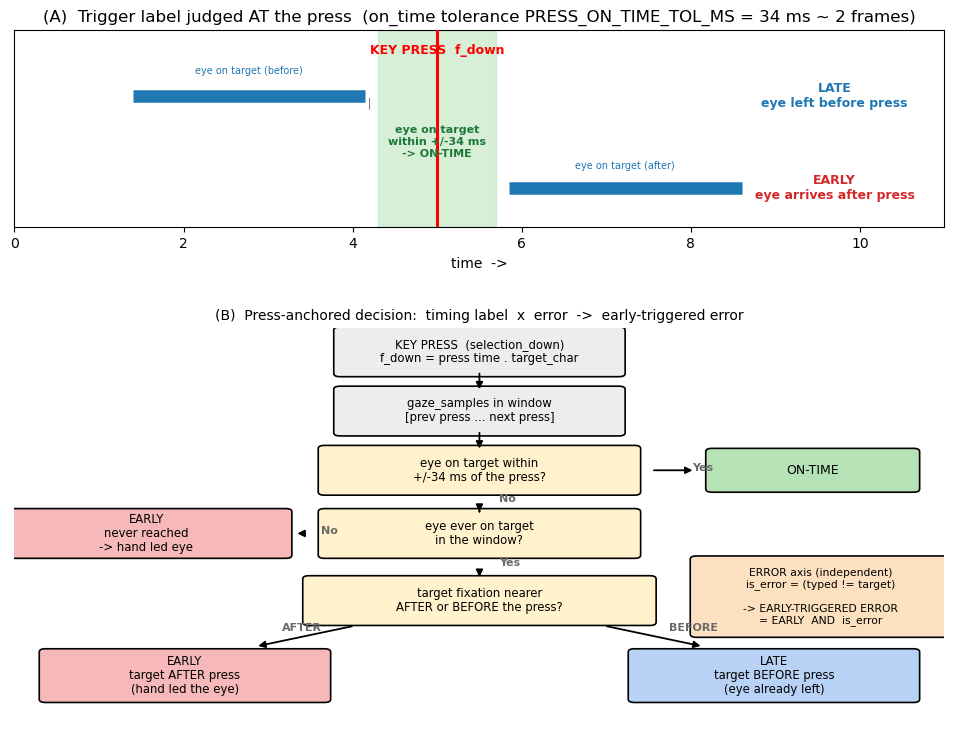

Saved -> analysis_output/early_late_mechanism.png


In [9]:
# ===== Schematic of the PRESS-ANCHORED early / on-time / late + error decision =====
from matplotlib.patches import FancyBboxPatch

TOL_MS = PRESS_ON_TIME_TOL_MS
fig = plt.figure(figsize=(12, 9))
gs = fig.add_gridspec(2, 1, height_ratios=[1.0, 2.0], hspace=0.34)

# ---------------- (A) timeline centred on the PRESS ----------------
axt = fig.add_subplot(gs[0])
press, band = 5.0, 0.7                                   # band = visual half-width of +/-TOL
axt.axvspan(press - band, press + band, color="#b6e3b6", alpha=0.55, zorder=0)   # on_time zone
axt.axvline(press, color="red", lw=2.2, zorder=3)
axt.text(press, 1.18, "KEY PRESS  f_down", ha="center", color="red", fontsize=9, fontweight="bold")
axt.text(press, 0.0, f"eye on target\nwithin +/-{int(TOL_MS)} ms\n-> ON-TIME",
         ha="center", va="center", fontsize=8, color="#1b7837", fontweight="bold")

# LATE scenario (eye on target BEFORE the press, gone by press)
axt.plot([1.4, press - band - 0.15], [0.62, 0.62], color="#1f77b4", lw=9, solid_capstyle="butt")
axt.text((1.4 + press - band - 0.15) / 2, 0.92, "eye on target (before)", ha="center", fontsize=7, color="#1f77b4")
axt.annotate("", xy=(press - band - 0.1, 0.4), xytext=(press - band - 0.1, 0.62),
             arrowprops=dict(arrowstyle="-", color="grey", lw=0.8))
axt.text(9.7, 0.62, "LATE\neye left before press", ha="center", va="center",
         color="#1f77b4", fontsize=9, fontweight="bold")

# EARLY scenario (eye reaches target AFTER the press)
axt.plot([press + band + 0.15, 8.6], [-0.62, -0.62], color="#1f77b4", lw=9, solid_capstyle="butt")
axt.text((press + band + 0.15 + 8.6) / 2, -0.36, "eye on target (after)", ha="center", fontsize=7, color="#1f77b4")
axt.text(9.7, -0.62, "EARLY\neye arrives after press", ha="center", va="center",
         color="#d62728", fontsize=9, fontweight="bold")

axt.set_xlim(0, 11); axt.set_ylim(-1.15, 1.5); axt.set_yticks([])
axt.set_xlabel("time  ->")
axt.set_title(f"(A)  Trigger label judged AT the press  (on_time tolerance PRESS_ON_TIME_TOL_MS = {int(TOL_MS)} ms ~ 2 frames)")

# ---------------- (B) decision flowchart ----------------
axf = fig.add_subplot(gs[1])
axf.set_xlim(0, 12); axf.set_ylim(0, 10); axf.axis("off")

def box(x, y, text, fc="#f0f0f0", w=3.6, h=1.1, fs=8.4):
    axf.add_patch(FancyBboxPatch((x - w / 2, y - h / 2), w, h,
                                 boxstyle="round,pad=0.08", fc=fc, ec="black", lw=1.2))
    axf.text(x, y, text, ha="center", va="center", fontsize=fs)

def arrow(p1, p2, label=None, dx=0.25, dy=0.0):
    axf.annotate("", xy=p2, xytext=p1,
                 arrowprops=dict(arrowstyle="-|>", color="black", lw=1.3, shrinkA=14, shrinkB=14))
    if label:
        axf.text((p1[0] + p2[0]) / 2 + dx, (p1[1] + p2[1]) / 2 + dy, label,
                 fontsize=8, color="dimgrey", fontweight="bold")

RED, GREEN, BLUE, GREY, YEL = "#f6b8b8", "#b6e3b6", "#b8d2f6", "#ededed", "#fff2cc"
box(6.0, 9.4, "KEY PRESS  (selection_down)\nf_down = press time . target_char", GREY)
box(6.0, 7.9, "gaze_samples in window\n[prev press ... next press]", GREY)
box(6.0, 6.4, f"eye on target within\n+/-{int(TOL_MS)} ms of the press?", YEL, w=4.0)
box(10.3, 6.4, "ON-TIME", GREEN, w=2.6, h=0.95, fs=9)
box(6.0, 4.8, "eye ever on target\nin the window?", YEL, w=4.0)
box(1.7, 4.8, "EARLY\nnever reached\n-> hand led eye", RED)
box(6.0, 3.1, "target fixation nearer\nAFTER or BEFORE the press?", YEL, w=4.4)
box(2.2, 1.2, "EARLY\ntarget AFTER press\n(hand led the eye)", RED, h=1.2)
box(9.8, 1.2, "LATE\ntarget BEFORE press\n(eye already left)", BLUE, h=1.2)
box(10.4, 3.2, "ERROR axis (independent)\nis_error = (typed != target)\n\n-> EARLY-TRIGGERED ERROR\n= EARLY  AND  is_error",
    "#fde0c0", w=3.2, h=1.9, fs=7.8)

arrow((6.0, 8.85), (6.0, 8.45))
arrow((6.0, 7.35), (6.0, 6.95))
arrow((8.0, 6.4), (9.0, 6.4), "Yes")
arrow((6.0, 5.85), (6.0, 5.35), "No")
arrow((4.0, 4.8), (3.4, 4.8), "No")
arrow((6.0, 4.25), (6.0, 3.7), "Yes")
arrow((4.6, 2.55), (2.9, 1.85), "AFTER", dx=-0.3, dy=0.15)
arrow((7.4, 2.55), (9.1, 1.85), "BEFORE", dx=0.2, dy=0.15)

axf.set_title("(B)  Press-anchored decision:  timing label  x  error  ->  early-triggered error", fontsize=10)

plt.savefig(OUT_DIR / "early_late_mechanism.png", dpi=140, bbox_inches="tight")
plt.show()
print("Saved -> analysis_output/early_late_mechanism.png")


## 4. Fixation duration & corrective saccades (RQ2)

* **Fixation duration** — a dispersion-based (I-DT) detector groups consecutive
  gaze samples whose spread stays under `FIX_DISPERSION_PX` for at least
  `FIX_MIN_DURATION_MS`. We report the mean fixation duration per session.
* **Corrective saccades (proxy)** — per committed letter, how many times the
  gaze *re-enters* the target key after first leaving it before the commit. A
  clean, confident selection has 0; hunting/correcting raises it.

Both are approximate (webcam gaze is noisy) — treat as proxies and tune the
thresholds with the team.

In [10]:
def detect_fixations(gz: pd.DataFrame):
    """I-DT dispersion fixation detector. Returns list of durations (ms)."""
    g = gz.dropna(subset=["gaze_x", "gaze_y"]).sort_values("timestamp")
    xs = g["gaze_x"].to_numpy(dtype=float)
    ys = g["gaze_y"].to_numpy(dtype=float)
    ts = g["timestamp"].to_numpy(dtype=float)
    n = len(ts)
    durations = []
    i = 0
    while i < n:
        j = i + 1
        while j < n:
            disp = (xs[i:j+1].max() - xs[i:j+1].min()) + (ys[i:j+1].max() - ys[i:j+1].min())
            if disp > FIX_DISPERSION_PX:
                break
            j += 1
        dur = ts[j-1] - ts[i]
        if dur >= FIX_MIN_DURATION_MS and (j - i) >= 2:
            durations.append(dur)
            i = j
        else:
            i += 1
    return durations


def corrective_saccades_for_trial(ev: pd.DataFrame):
    """Per committed letter, count re-entries to the target key before commit."""
    gz = ev[ev["event_type"] == "gaze_sample"].sort_values("timestamp")
    sels = ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
    sels = sels.sort_values("timestamp")
    sel_t = sels["timestamp"].to_numpy(dtype=float)
    counts = []
    for i, (_, s) in enumerate(sels.iterrows()):
        t_sel = float(s["timestamp"])
        lo = sel_t[i-1] if i > 0 else (t_sel - GAZE_SEARCH_BEFORE_MS)
        seg = gz[(gz["timestamp"] >= lo) & (gz["timestamp"] <= t_sel)]
        target = s.get("target_char")
        if pd.isna(target) or seg.empty:
            continue
        on = (seg["hovered_key"].astype("object") == target).to_numpy()
        # number of rising edges (off->on) beyond the first arrival = re-entries
        entries = int(np.sum((~on[:-1]) & on[1:])) if on.size > 1 else int(on[:1].sum())
        counts.append(max(entries - 1, 0))
    return counts


fix_records = []
for _, r in analysis_trials.iterrows():
    ev = get_events(r)
    if ev.empty:
        continue
    gz = ev[ev["event_type"] == "gaze_sample"]
    durs = detect_fixations(gz)
    corr = corrective_saccades_for_trial(ev)
    fix_records.append({
        "participant_id": r["participant_id"], "day": r["day"],
        "session_label": r["session_label"], "trial_id": r["trial_id"],
        "mean_fixation_ms": np.mean(durs) if durs else np.nan,
        "n_fixations": len(durs),
        "mean_corrective_saccades": np.mean(corr) if corr else np.nan,
    })

trial_gaze = pd.DataFrame(fix_records)
if len(trial_gaze):
    display(trial_gaze.head())


,participant_id,day,session_label,trial_id,mean_fixation_ms,n_fixations,mean_corrective_saccades
0,P01,1,experiment_1,trial_001,93.200000,5,1.6
1,P01,1,experiment_1,trial_002,100.684211,19,4.2
2,P01,1,experiment_1,trial_003,83.125000,8,1.2
3,P01,1,experiment_1,trial_004,86.400000,10,2.6
4,P01,1,experiment_1,trial_005,91.750000,4,1.6


## 5. Aggregate per session & per day

Roll everything up to **(participant, day, session)** and **(participant, day)**.
The per-day table is what drives the learning-curve figures and RQ3 correlations.

In [11]:
# --- selection-derived rates per (participant, day, session) ---
# Built with an explicit loop (rather than groupby.apply) so it behaves the same
# across pandas versions and never operates on the grouping columns.
def sel_rates(g):
    n = len(g)
    n_err = int(g["is_error"].sum())
    n_late = int(((g["label"] == "late") & g["is_error"]).sum())
    n_early = int(((g["label"] == "early") & g["is_error"]).sum())
    n_other = n_err - n_late - n_early          # errors that are on_time / no_target_fix
    return {
        "n_selections": n,
        "n_errors": n_err,
        "error_rate_per_keystroke": n_err / n if n else np.nan,
        "n_late_err": n_late,
        "n_early_err": n_early,
        "n_other_err": n_other,
        # ---- error TYPE composition: shares among errors (sum to 1) ----
        "early_share_of_err": n_early / (n_early + n_late) if (n_early + n_late) else np.nan,  # = early/(early+late)
        "late_share_of_err":  n_late  / (n_early + n_late) if (n_early + n_late) else np.nan,  # = late/(early+late)
        "other_share_of_err": n_other / n_err if n_err else np.nan,   # (other / all errors; reference only)
        # ---- error TYPE as a rate per keystroke (always defined; 0 if none) ----
        "early_err_per_key":  n_early / n if n else np.nan,
        "late_err_per_key":   n_late  / n if n else np.nan,
        "other_err_per_key":  n_other / n if n else np.nan,
        "mean_trigger_offset_ms": g["offset_ms"].mean(skipna=True),
        "median_trigger_offset_ms": g["offset_ms"].median(skipna=True),
        # ---- GazePinch gaze-key latencies (the section-3 t-metrics) ----
        "mean_gaze_pinch_latency_ms": g["t5"].mean(skipna=True),    # t5 = f_down - g2 (headline)
        "median_gaze_pinch_latency_ms": g["t5"].median(skipna=True),
        "mean_approach_latency_ms": g["t2"].mean(skipna=True),      # t2 = f_down - g1
        "mean_fixation_dwell_ms": g["t7"].mean(skipna=True),        # t7 = g2 - g1
        "mean_key_hold_ms": g["hold_ms"].mean(skipna=True),         # f_up - f_down
    }

if len(selections):
    _recs = []
    for (pid, day, sl), g in selections.groupby(["participant_id", "day", "session_label"]):
        _recs.append({"participant_id": pid, "day": day, "session_label": sl, **sel_rates(g)})
    sel_by_session = pd.DataFrame(_recs)
else:
    sel_by_session = pd.DataFrame()

# --- performance per (participant, day, session) ---
perf_by_session = (perf.groupby(["participant_id", "day", "session_label"])
                   .agg(mean_wpm=("wpm", "mean"),
                        mean_errors_per_phrase=("errors_per_phrase", "mean"),
                        error_rate_per_phrase=("has_error", "mean"),
                        mean_cer=("character_error_rate", "mean"),
                        mean_accuracy=("accuracy", "mean"),
                        n_trials=("trial_id", "count"))
                   .reset_index())

# --- gaze dynamics per session ---
gaze_by_session = (trial_gaze.groupby(["participant_id", "day", "session_label"])
                   .agg(mean_fixation_ms=("mean_fixation_ms", "mean"),
                        mean_corrective_saccades=("mean_corrective_saccades", "mean"))
                   .reset_index()) if len(trial_gaze) else pd.DataFrame()

session_metrics = perf_by_session
for extra in (sel_by_session, gaze_by_session):
    if len(extra):
        session_metrics = session_metrics.merge(
            extra, on=["participant_id", "day", "session_label"], how="left")

session_metrics = session_metrics.sort_values(["participant_id", "day", "session_label"])
display(session_metrics)


,participant_id,day,session_label,mean_wpm,mean_errors_per_phrase,error_rate_per_phrase,mean_cer,mean_accuracy,n_trials,n_selections,n_errors,error_rate_per_keystroke,n_late_err,n_early_err,n_other_err,early_share_of_err,late_share_of_err,other_share_of_err,early_err_per_key,late_err_per_key,other_err_per_key,mean_trigger_offset_ms,median_trigger_offset_ms,mean_gaze_pinch_latency_ms,median_gaze_pinch_latency_ms,mean_approach_latency_ms,mean_fixation_dwell_ms,mean_key_hold_ms,mean_fixation_ms,mean_corrective_saccades
0,P01,1,experiment_1,6.667576,0.4,0.3,0.08,0.92,10,50,4,0.08,2,0,2,0.000000,1.000000,0.500000,0.00,0.04,0.04,21.90,0.0,537.574468,553.0,743.219512,245.048780,86.388889,91.339135,2.56
1,P01,1,experiment_2,6.547706,0.5,0.4,0.10,0.90,10,50,5,0.10,1,2,2,0.666667,0.333333,0.400000,0.04,0.02,0.04,20.48,0.0,527.630435,575.5,652.609756,152.243902,89.647059,94.419293,2.78
2,P01,1,experiment_3,6.897011,0.2,0.2,0.04,0.96,10,50,2,0.04,2,0,0,0.000000,1.000000,0.000000,0.00,0.04,0.00,14.20,0.0,599.565217,550.5,774.526316,225.052632,90.833333,99.988056,3.04
3,P01,1,experiment_4,7.125369,0.6,0.6,0.12,0.88,10,50,6,0.12,2,1,3,0.333333,0.666667,0.500000,0.02,0.04,0.06,19.14,0.0,590.414634,601.0,790.628571,228.628571,86.300000,97.545840,2.06
4,P01,1,experiment_5,6.218479,0.7,0.5,0.14,0.86,10,50,7,0.14,0,2,5,1.000000,0.000000,0.714286,0.04,0.00,0.10,7.38,0.0,648.342105,560.5,881.906250,267.062500,87.078947,91.076097,3.96
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,P06,3,experiment_1,4.773250,0.6,0.6,0.12,0.88,10,50,6,0.12,3,0,3,0.000000,1.000000,0.500000,0.00,0.06,0.06,37.46,0.0,777.270270,730.0,934.259259,210.777778,177.133333,101.033197,3.60
86,P06,3,experiment_2,5.229619,0.8,0.5,0.16,0.84,10,50,8,0.16,5,2,1,0.285714,0.714286,0.125000,0.04,0.10,0.02,243.78,0.0,753.297297,737.0,901.033333,173.500000,188.562500,100.489530,3.48
87,P06,3,experiment_3,7.100219,0.6,0.4,0.12,0.88,10,50,6,0.12,0,4,2,1.000000,0.000000,0.333333,0.08,0.00,0.04,-4.06,0.0,695.904762,655.5,881.937500,190.531250,173.795455,104.080616,1.86
88,P06,3,experiment_4,9.434156,0.2,0.1,0.04,0.96,10,50,2,0.04,1,1,0,0.500000,0.500000,0.000000,0.02,0.02,0.00,4.22,0.0,630.333333,644.0,792.594595,171.351351,166.880000,97.406371,1.26


In [12]:
# --- per (participant, day): the learning-contrast unit ---
agg_cols = {c: "mean" for c in session_metrics.columns
            if c not in ("participant_id", "day", "session_label", "n_trials", "n_selections",
                          "n_errors", "n_late_err", "n_early_err", "n_other_err")}
day_metrics = (session_metrics.groupby(["participant_id", "day"])
               .agg(agg_cols).reset_index()
               .sort_values(["participant_id", "day"]))
display(day_metrics)

# Group means across participants, by day (for the headline learning curves).
by_day = day_metrics.groupby("day").mean(numeric_only=True).reset_index()
display(by_day)


,participant_id,day,mean_wpm,mean_errors_per_phrase,error_rate_per_phrase,mean_cer,mean_accuracy,error_rate_per_keystroke,early_share_of_err,late_share_of_err,other_share_of_err,early_err_per_key,late_err_per_key,other_err_per_key,mean_trigger_offset_ms,median_trigger_offset_ms,mean_gaze_pinch_latency_ms,median_gaze_pinch_latency_ms,mean_approach_latency_ms,mean_fixation_dwell_ms,mean_key_hold_ms,mean_fixation_ms,mean_corrective_saccades
0,P01,1,6.691228,0.48,0.40,0.096,0.904,0.096,0.400000,0.600000,0.422857,0.020,0.028,0.048,16.620000,0.0,580.705372,568.1,768.578081,223.607277,88.049646,94.873684,2.880
1,P01,2,9.014455,0.48,0.36,0.096,0.904,0.096,0.175000,0.825000,0.438393,0.012,0.044,0.040,14.152000,0.0,553.899920,530.4,728.362674,195.834639,86.417987,93.563723,1.660
2,P01,3,8.412730,0.50,0.40,0.100,0.900,0.100,0.253333,0.746667,0.360000,0.020,0.048,0.032,16.523918,0.0,685.525308,662.7,835.875142,174.844469,89.687697,98.549287,1.728
3,P02,1,6.673462,0.58,0.50,0.116,0.884,0.116,0.354762,0.645238,0.407143,0.028,0.052,0.036,11.332000,0.0,758.289875,758.9,920.078096,173.264968,80.597026,91.999253,2.652
4,P02,2,10.739680,0.14,0.12,0.028,0.972,0.028,0.500000,0.500000,0.791667,0.004,0.004,0.020,3.388327,0.0,585.825232,564.8,711.176798,133.048435,87.723265,99.383491,0.712
5,P02,3,10.793299,0.14,0.12,0.028,0.972,0.028,0.375000,0.625000,0.500000,0.012,0.008,0.008,0.592000,0.0,619.467900,585.5,728.109751,117.694056,86.506612,98.719930,0.900
6,P03,1,10.838184,0.18,0.14,0.036,0.964,0.036,0.833333,0.166667,0.458333,0.020,0.004,0.012,-3.434776,0.0,559.643811,567.3,716.032431,156.424327,124.606076,104.058743,0.688
7,P03,2,10.108549,0.28,0.22,0.056,0.944,0.056,0.666667,0.333333,0.573333,0.016,0.012,0.028,3.888000,0.0,602.524468,555.3,713.079001,130.296906,114.796093,99.307470,1.088
8,P03,3,14.138126,0.00,0.00,0.000,1.000,0.000,NaN,NaN,NaN,0.000,0.000,0.000,0.000000,0.0,549.566768,517.8,658.140478,96.978153,98.836000,102.353511,0.364
9,P04,1,4.242350,0.78,0.54,0.156,0.844,0.156,0.283333,0.716667,0.330556,0.028,0.076,0.052,41.960000,0.0,462.237539,407.8,644.425433,217.653497,127.103250,87.614391,4.792


,day,mean_wpm,mean_errors_per_phrase,error_rate_per_phrase,mean_cer,mean_accuracy,error_rate_per_keystroke,early_share_of_err,late_share_of_err,other_share_of_err,early_err_per_key,late_err_per_key,other_err_per_key,mean_trigger_offset_ms,median_trigger_offset_ms,mean_gaze_pinch_latency_ms,median_gaze_pinch_latency_ms,mean_approach_latency_ms,mean_fixation_dwell_ms,mean_key_hold_ms,mean_fixation_ms,mean_corrective_saccades
0,1,6.037324,1.120000,0.576667,0.224000,0.776000,0.225333,0.430855,0.569145,0.335433,0.065333,0.105333,0.054667,128.253290,0.0,563.601361,543.316667,739.738409,206.968547,115.398143,95.691932,3.140000
1,2,8.348183,0.716667,0.443333,0.143333,0.856667,0.144000,0.453010,0.546990,0.433059,0.042000,0.062000,0.040000,50.018458,0.0,575.850830,559.650000,729.467859,187.751968,112.669866,98.934342,1.736000
2,3,9.414573,0.330000,0.270000,0.066000,0.934000,0.066000,0.462175,0.537825,0.479667,0.018667,0.021333,0.026000,13.000680,0.0,626.345252,607.800000,774.082323,166.383517,123.453743,98.798432,1.497333


## 6. Figures — learning curves & error-pattern shift

* **WPM / accuracy / error rate** vs day — per participant (thin) + mean (bold).
* **Early vs late share** of errors by day — the RQ1 headline.

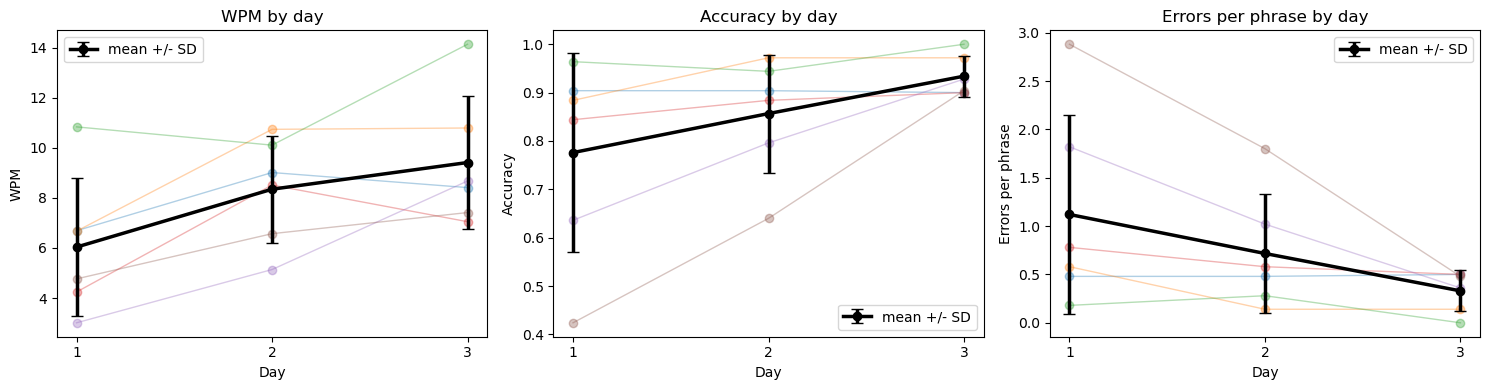

In [13]:
def learning_curve(metric, ylabel, ax):
    for pid, g in day_metrics.groupby("participant_id"):
        g = g.sort_values("day")
        ax.plot(g["day"], g[metric], marker="o", alpha=0.35, linewidth=1)
    gd = day_metrics.groupby("day")[metric]
    m, sd = gd.mean(), gd.std()
    ax.errorbar(m.index, m.values, yerr=sd.values, marker="o", color="black",
                linewidth=2.5, capsize=4, label="mean +/- SD")
    ax.set_xlabel("Day"); ax.set_ylabel(ylabel); ax.set_title(ylabel + " by day")
    ax.legend()

curves = [("mean_wpm", "WPM"),
          ("mean_accuracy", "Accuracy"),
          ("mean_errors_per_phrase", "Errors per phrase")]
curves = [(m, l) for m, l in curves if m in day_metrics.columns]
if curves and len(day_metrics):
    fig, axes = plt.subplots(1, len(curves), figsize=(5 * len(curves), 4))
    if len(curves) == 1:
        axes = [axes]
    for (m, l), ax in zip(curves, axes):
        learning_curve(m, l, ax)
    plt.tight_layout(); plt.savefig(OUT_DIR / "learning_curves.png", dpi=150); plt.show()
else:
    print("Not enough data for learning curves yet.")


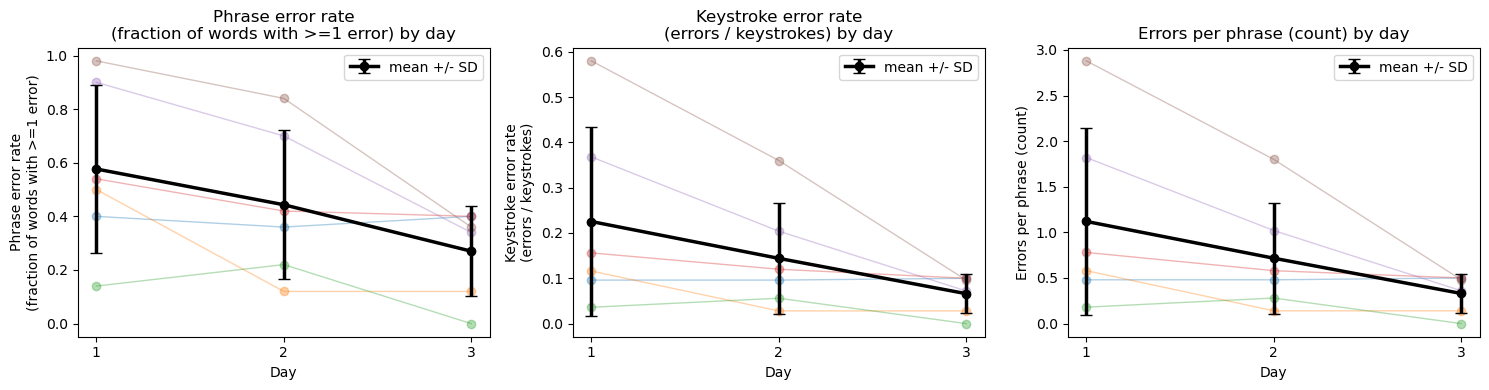

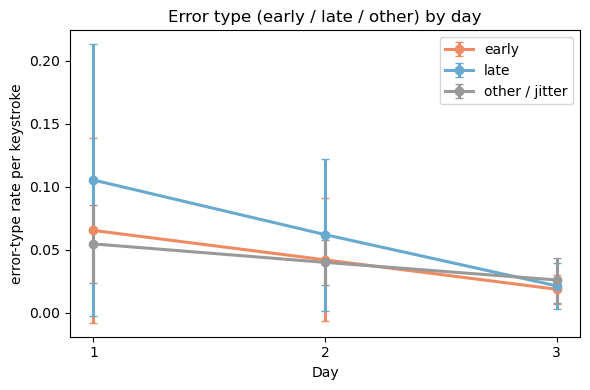

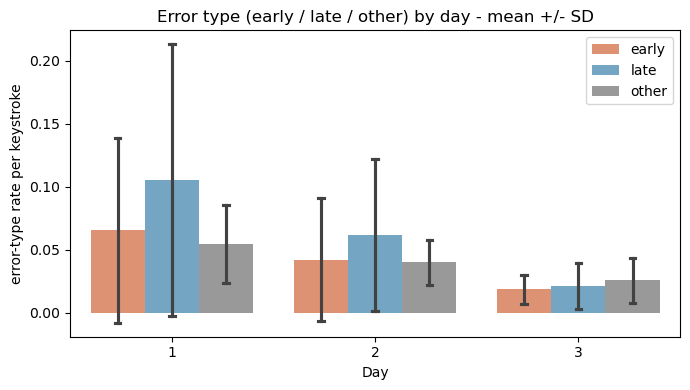

In [14]:
# ===== Line charts: each ERROR RATE vs day (x = day) =====
# Per-participant (thin) + across-participant mean (bold), like the learning curves.
err_curves = [("error_rate_per_phrase",    "Phrase error rate\n(fraction of words with >=1 error)"),
              ("error_rate_per_keystroke", "Keystroke error rate\n(errors / keystrokes)"),
              ("mean_errors_per_phrase",   "Errors per phrase (count)")]
err_curves = [(m, l) for m, l in err_curves if m in day_metrics.columns]
if err_curves:
    fig, axes = plt.subplots(1, len(err_curves), figsize=(5 * len(err_curves), 4))
    if len(err_curves) == 1:
        axes = [axes]
    for (m, l), ax in zip(err_curves, axes):
        learning_curve(m, l, ax)
    plt.tight_layout(); plt.savefig(OUT_DIR / "error_rates_by_day.png", dpi=150); plt.show()

# Error-TYPE rate per keystroke (early / late / other) vs day - group means, one line each.
type_dvs = [("early_err_per_key", "early", "#ef8a62"),
            ("late_err_per_key",  "late",  "#67a9cf"),
            ("other_err_per_key", "other / jitter", "#999999")]
type_dvs = [(m, l, c) for m, l, c in type_dvs if m in day_metrics.columns]
if type_dvs:
    plt.figure(figsize=(6, 4))
    for m, l, c in type_dvs:
        g = day_metrics.groupby("day")[m]
        plt.errorbar(g.mean().index, g.mean().values, yerr=g.std().values,
                     marker="o", color=c, lw=2.2, capsize=3, label=l)
    plt.xlabel("Day"); plt.ylabel("error-type rate per keystroke")
    plt.title("Error type (early / late / other) by day")
    plt.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / "error_type_rates_by_day.png", dpi=150); plt.show()

    import seaborn as sns  # (imported here too; this cell runs before the import in section 6)
    # Same thing as a seaborn BAR plot with SD error bars (mean +/- 1 SD across participants).
    long = day_metrics.melt(id_vars=["participant_id", "day"],
                            value_vars=["early_err_per_key", "late_err_per_key", "other_err_per_key"],
                            var_name="etype", value_name="rate")
    long["etype"] = long["etype"].str.replace("_err_per_key", "", regex=False)
    plt.figure(figsize=(7, 4))
    sns.barplot(data=long, x="day", y="rate", hue="etype", errorbar="sd", capsize=.08,
                hue_order=["early", "late", "other"],
                palette={"early": "#ef8a62", "late": "#67a9cf", "other": "#999999"})
    plt.xlabel("Day"); plt.ylabel("error-type rate per keystroke")
    plt.title("Error type (early / late / other) by day - mean +/- SD")
    plt.legend(title="", loc="upper right")
    plt.tight_layout(); plt.savefig(OUT_DIR / "error_type_rates_bar_by_day.png", dpi=150); plt.show()


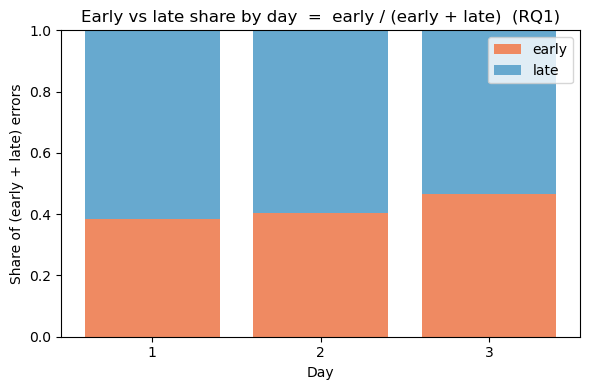

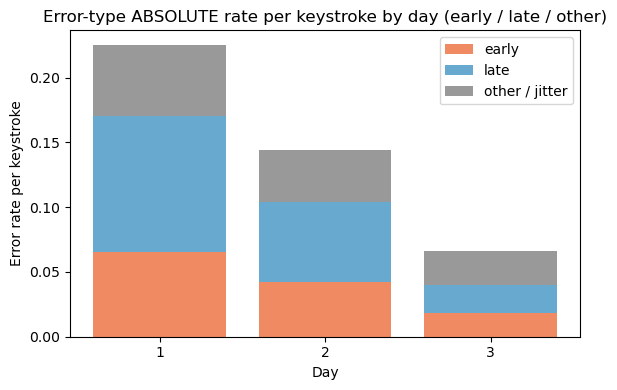

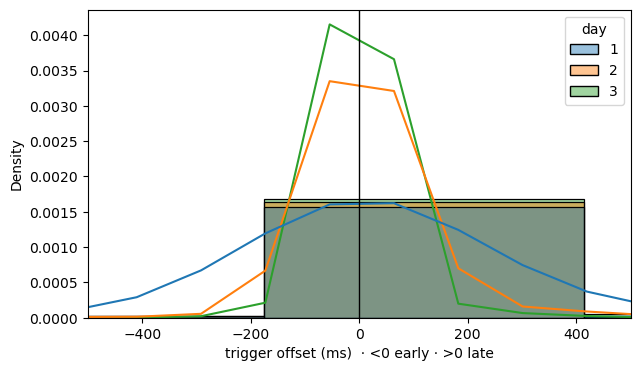

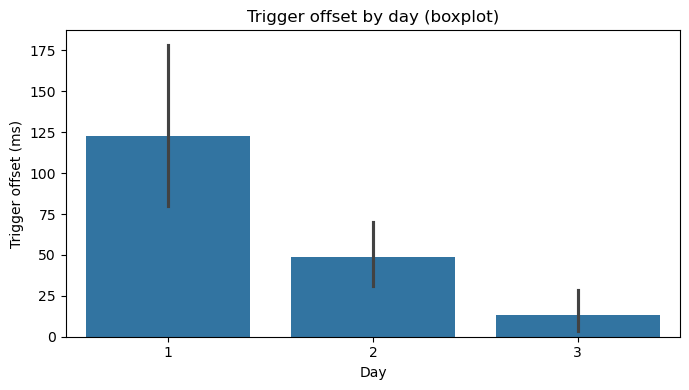

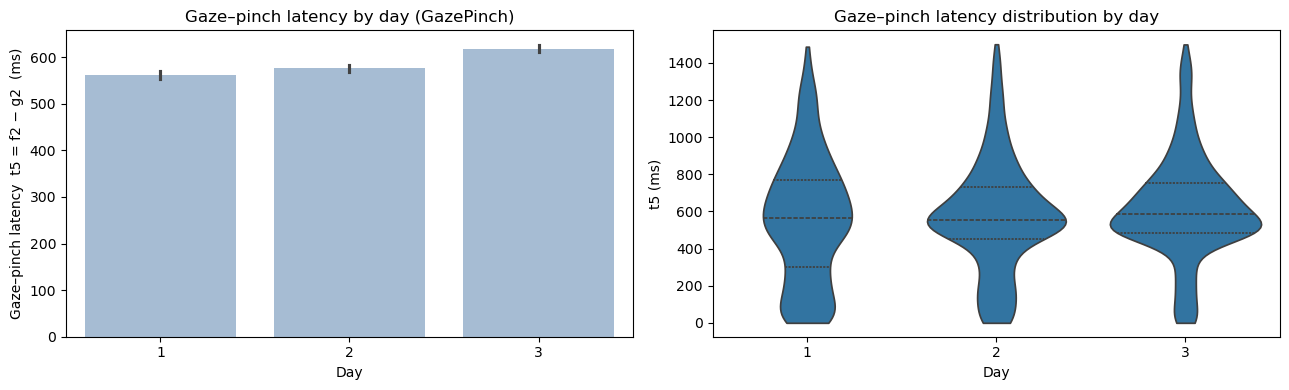

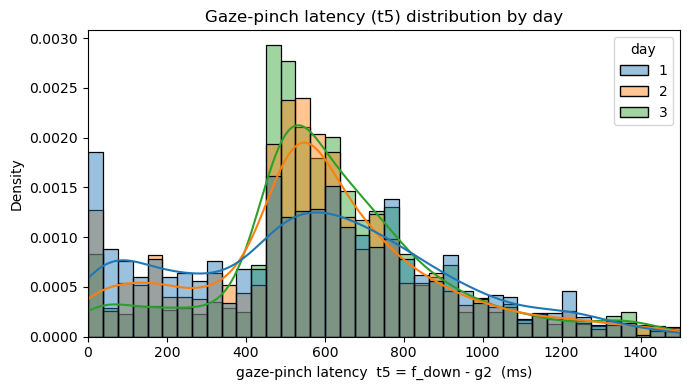

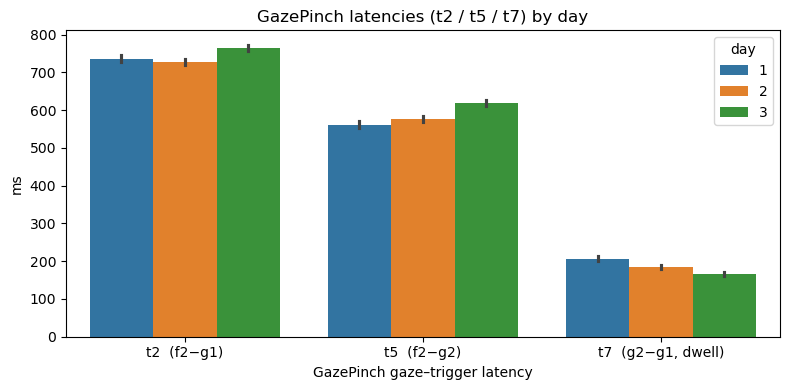

In [15]:
# Early vs late share of errors, by day (stacked).
import seaborn as sns
if len(day_metrics) and "late_share_of_err" in day_metrics.columns:
    # Error SHARE by day - EARLY vs LATE only:  each / (early + late).
    _e = selections[selections["is_error"]].copy()
    _e["etype"] = _e["label"].where(_e["label"].isin(["early", "late"]), "other")
    cnt = (_e.groupby(["day", "etype"]).size().unstack(fill_value=0)
           .reindex(columns=["early", "late", "other"], fill_value=0))
    shr = cnt[["early", "late"]].div(cnt["early"] + cnt["late"], axis=0)   # early/(early+late)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(shr.index, shr["early"], label="early", color="#ef8a62")
    ax.bar(shr.index, shr["late"], bottom=shr["early"], label="late", color="#67a9cf")
    ax.set_xlabel("Day"); ax.set_ylabel("Share of (early + late) errors"); ax.set_ylim(0, 1)
    ax.set_title("Early vs late share by day  =  early / (early + late)  (RQ1)")
    ax.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / "early_late_by_day.png", dpi=150); plt.show()

    # Same breakdown but ABSOLUTE: error-type RATE per keystroke (stacked).
    # Total bar height = overall error rate per keystroke; shows composition + decline together.
    n_by_day = selections.groupby("day").size()
    rate = (_e.groupby(["day", "etype"]).size().unstack(fill_value=0)
            .reindex(columns=["early", "late", "other"], fill_value=0)
            .div(n_by_day, axis=0))
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.bar(rate.index, rate["early"], label="early", color="#ef8a62")
    ax.bar(rate.index, rate["late"], bottom=rate["early"], label="late", color="#67a9cf")
    ax.bar(rate.index, rate["other"], bottom=rate["early"] + rate["late"],
           label="other / jitter", color="#999999")
    ax.set_xlabel("Day"); ax.set_ylabel("Error rate per keystroke")
    ax.set_title("Error-type ABSOLUTE rate per keystroke by day (early / late / other)")
    ax.legend(); plt.tight_layout()
    plt.savefig(OUT_DIR / "error_type_absolute_by_day.png", dpi=150); plt.show()

    # Trigger-offset distribution by day (RQ2, signed early/late offset).
    plt.figure(figsize=(7, 4))
    sns.histplot(data=selections.dropna(subset=["offset_ms"]), x="offset_ms", hue="day",
                 bins=40, kde=True, stat="density", common_norm=False, alpha=0.45)
    plt.axvline(0, color="k", lw=1)
    plt.xlabel("trigger offset (ms)  · <0 early · >0 late")
    plt.xlim(-500,500)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.barplot(data=selections.dropna(subset=["offset_ms"]), x="day", y="offset_ms")
    plt.xlabel("Day"); plt.ylabel("Trigger offset (ms)")
    plt.title("Trigger offset by day (boxplot)")
    plt.tight_layout(); plt.savefig(OUT_DIR / "trigger_offset_by_day_boxplot.png", dpi=150); plt.show()

else:
    print("Not enough data for error-pattern figures yet.")

# ---- GazePinch gaze–pinch latency (t5 = f2 - g2) by day ----
# This is the headline gaze–trigger metric ported from DATAAnalysis-GazePinch:
# how long after the eye settled on the target the trigger fired. Day is the
# only factor (no Task / error split).
if len(selections) and selections["t5"].notna().any():
    t5d = selections.dropna(subset=["t5"])

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    # (a) mean t5 per day (error bars = standard error)
    sns.barplot(data=t5d, x="day", y="t5", ax=axes[0], color="#9ebcda", errorbar="se")
    axes[0].set_xlabel("Day"); axes[0].set_ylabel("Gaze–pinch latency  t5 = f2 − g2  (ms)")
    axes[0].set_title("Gaze–pinch latency by day (GazePinch)")
    # (b) distribution of t5 by day
    sns.violinplot(data=t5d, x="day", y="t5", ax=axes[1], inner="quartile", cut=0)
    axes[1].set_xlabel("Day"); axes[1].set_ylabel("t5 (ms)")
    axes[1].set_title("Gaze–pinch latency distribution by day")
    plt.tight_layout(); plt.savefig(OUT_DIR / "gaze_pinch_latency_by_day.png", dpi=150); plt.show()

    # Gaze-pinch latency (t5) distribution by day - histogram (same style as the offset hist).
    plt.figure(figsize=(7, 4))
    sns.histplot(data=t5d, x="t5", hue="day", bins=40, kde=True,
                 stat="density", common_norm=False, alpha=0.45)
    plt.xlabel("gaze-pinch latency  t5 = f_down - g2  (ms)")
    plt.xlim(0, 1500)
    plt.title("Gaze-pinch latency (t5) distribution by day")
    plt.tight_layout(); plt.savefig(OUT_DIR / "gaze_pinch_latency_hist_by_day.png", dpi=150); plt.show()

    # Per-day mean of the three GazePinch latencies, side by side.
    lat_long = t5d.melt(id_vars="day", value_vars=["t2", "t5", "t7"],
                        var_name="metric", value_name="ms")
    name_map = {"t2": "t2  (f2−g1)", "t5": "t5  (f2−g2)", "t7": "t7  (g2−g1, dwell)"}
    lat_long["metric"] = lat_long["metric"].map(name_map)
    plt.figure(figsize=(8, 4))
    sns.barplot(data=lat_long, x="metric", y="ms", hue="day", errorbar="se")
    plt.xlabel("GazePinch gaze–trigger latency"); plt.ylabel("ms")
    plt.title("GazePinch latencies (t2 / t5 / t7) by day")
    plt.tight_layout(); plt.savefig(OUT_DIR / "gazepinch_latencies_by_day.png", dpi=150); plt.show()
else:
    print("No GazePinch latencies available (need gaze_samples with detectable saccades).")


### 6b. Gaze-vs-key timeline (like the GazePinch trace)

The same visualisation as the GazePinch notebook, adapted to this keyboard task:

* **blue** — continuous **gaze position** over time (`gaze_x` or `gaze_y`, px);
* **orange step** — the **target key position** (`target_key_x/y`) — a staircase
  because each letter's key sits at a fixed screen position (the analogue of
  GazePinch's `GTPosition` step);
* **red** vertical lines — **KEY DOWN** (`f_down`, the trigger / commit);
* **green** dotted lines — **KEY UP** (`f_up`, the release).

`gaze_*` and `target_key_*` share the same pixel coordinate space, so they overlay
directly. Idle gaps between trials are compressed (each trial is laid back-to-back
with a small pad) so the trace stays dense like the reference figure.


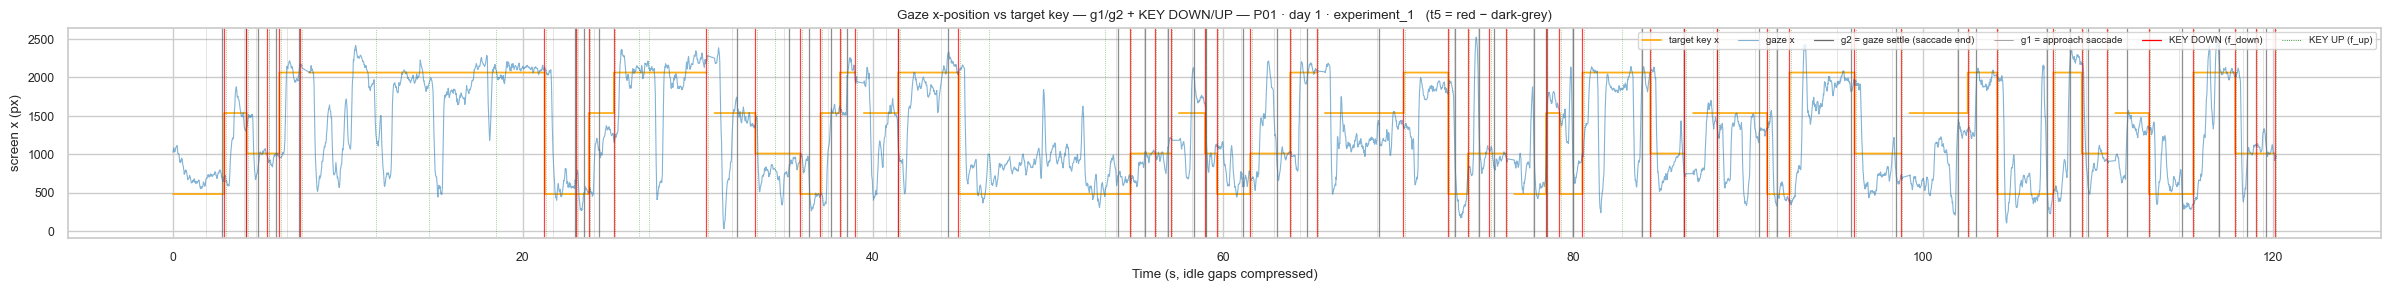

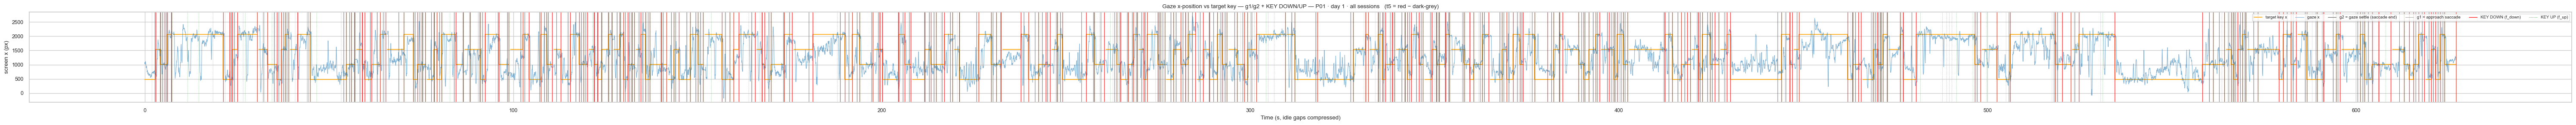

In [16]:
def plot_gaze_key_timeline(participant_id, day, session_label=None, axis="x",
                           figsize=(60, 3), pad_s=0.4, show_saccade=True, save=True):
    """GazePinch-style trace over time:
      blue        = gaze position
      orange step = target-key position
      grey        = g2 (gaze SETTLE = end of last saccade)  [+ faint = g1 approach]
      red         = KEY DOWN (f_down, the trigger)
      green dotted= KEY UP   (f_up, the release)
    So t5 = (red − dark-grey),  t7 = (dark-grey − faint-grey). Idle gaps between
    trials are removed (trials laid back-to-back + pad_s).
    """
    gcol, kcol = f"gaze_{axis}", f"target_key_{axis}"
    sub = analysis_trials[(analysis_trials["participant_id"] == str(participant_id)) &
                          (analysis_trials["day"] == str(day))]
    if session_label is not None:
        sub = sub[sub["session_label"] == session_label]
    sub = sub.sort_values(["session_label", "trial_id"])
    if sub.empty:
        print("No trials for", participant_id, day, session_label); return

    g_all, down, up, g2s, g1s, offset = [], [], [], [], [], 0.0
    for _, r in sub.iterrows():
        ev = get_events(r)
        if ev.empty:
            continue
        gz_full = ev[ev["event_type"] == "gaze_sample"]
        gz = gz_full[["timestamp", gcol, kcol]].dropna(subset=[gcol]).sort_values("timestamp")
        if gz.empty:
            continue
        t_lo = gz["timestamp"].min()
        rel = lambda s: (np.asarray(s, float) - t_lo) / 1000.0 + offset   # trial time -> plot time
        gz = gz.assign(t=rel(gz["timestamp"]))
        g_all.append(gz)

        sels = (ev[(ev["event_type"] == "selection_down") & ev["selected_character"].notna()]
                .sort_values("timestamp"))
        sel_ts = sels["timestamp"].to_numpy(float)
        down += rel(sel_ts).tolist()
        up   += rel(ev.loc[ev["event_type"] == "selection_up", "timestamp"]).tolist()

        if show_saccade:                                  # g1/g2 per key press (same as §3)
            gz_sp = add_gaze_speed(gz_full)
            for i, t_down in enumerate(sel_ts):
                prev_t = sel_ts[i - 1] if i > 0 else None
                g1, g2 = find_g1_g2(gz_sp, float(t_down), prev_t)
                if pd.notna(g2): g2s.append(float(rel(g2)))
                if pd.notna(g1): g1s.append(float(rel(g1)))
        offset = gz["t"].max() + pad_s
    if not g_all:
        print("No gaze samples for", participant_id, day, session_label); return
    g = pd.concat(g_all, ignore_index=True)

    plt.figure(figsize=figsize)
    sns.set(style="whitegrid", font_scale=0.8)
    plt.plot(g["t"], g[kcol], drawstyle="steps-post", color="orange",
             lw=1.3, alpha=0.9, label=f"target key {axis}")
    plt.plot(g["t"], g[gcol], color="tab:blue", lw=0.8, alpha=0.55, label=f"gaze {axis}")
    for x in g1s:  plt.axvline(x, color="grey", lw=0.5, alpha=0.30)          # g1 (approach saccade)
    for x in g2s:  plt.axvline(x, color="dimgrey", lw=0.9, alpha=0.75)       # g2 (gaze settle)
    for x in down: plt.axvline(x, color="red", lw=0.9, alpha=0.75)           # KEY DOWN
    for x in up:   plt.axvline(x, color="green", lw=0.6, alpha=0.5, ls=":")  # KEY UP
    # legend proxies for the vertical lines
    plt.plot([], [], color="dimgrey", lw=0.9, label="g2 = gaze settle (saccade end)")
    plt.plot([], [], color="grey", lw=0.5, label="g1 = approach saccade")
    plt.plot([], [], color="red", lw=0.9, label="KEY DOWN (f_down)")
    plt.plot([], [], color="green", lw=0.6, ls=":", label="KEY UP (f_up)")
    scope = session_label if session_label else "all sessions"
    plt.title(f"Gaze {axis}-position vs target key — g1/g2 + KEY DOWN/UP — "
              f"{participant_id} · day {day} · {scope}   (t5 = red − dark-grey)")
    plt.xlabel("Time (s, idle gaps compressed)"); plt.ylabel(f"screen {axis} (px)")
    plt.legend(loc="upper right", ncol=6, fontsize=7)
    plt.tight_layout()
    if save:
        fn = f"gaze_key_timeline_{participant_id}_day{day}_{session_label or 'allday'}_{axis}.png"
        plt.savefig(OUT_DIR / fn, dpi=120)
    plt.show()


# One session, zoomed in: dark-grey = eye settles (g2), red = KEY DOWN -> the gap is t5.
plot_gaze_key_timeline("P01", "1", "experiment_1", axis="x", figsize=(24, 3))

# A whole day laid out wide, like the reference figure:
plot_gaze_key_timeline("P01", "1", None, axis="x", figsize=(60, 3))


## 7. RQ3 — do error patterns track performance?

Across the (participant, day) points, relate the **late/early error share** and
**trigger offset** to **WPM** and **accuracy**. With few points this is
descriptive (Pearson *r* shown as a guide, not a significance claim).

Pearson r across (participant, day) points:
  late_share_of_err            vs mean_wpm          r = -0.470  (n=17)
  late_share_of_err            vs mean_accuracy     r = -0.269  (n=17)
  early_share_of_err           vs mean_wpm          r = 0.470  (n=17)
  early_share_of_err           vs mean_accuracy     r = 0.269  (n=17)
  mean_trigger_offset_ms       vs mean_wpm          r = -0.684  (n=18)
  mean_gaze_pinch_latency_ms   vs mean_wpm          r = 0.129  (n=18)
  mean_gaze_pinch_latency_ms   vs mean_accuracy     r = 0.402  (n=18)
  mean_fixation_dwell_ms       vs mean_wpm          r = -0.843  (n=18)
  error_rate_per_keystroke     vs mean_wpm          r = -0.715  (n=18)


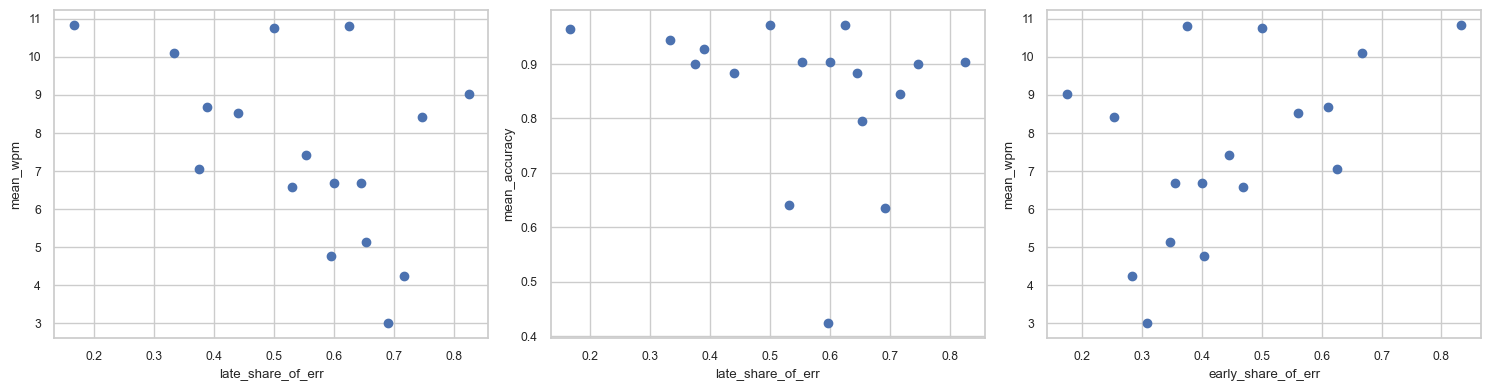

In [17]:
def safe_corr(df, a, b):
    s = df[[a, b]].dropna()
    if len(s) < 3:
        return np.nan, len(s)
    return s[a].corr(s[b]), len(s)

pairs = [("late_share_of_err", "mean_wpm"),
         ("late_share_of_err", "mean_accuracy"),
         ("early_share_of_err", "mean_wpm"),
         ("early_share_of_err", "mean_accuracy"),
         ("mean_trigger_offset_ms", "mean_wpm"),
         ("mean_gaze_pinch_latency_ms", "mean_wpm"),       # GazePinch t5 vs speed
         ("mean_gaze_pinch_latency_ms", "mean_accuracy"),  # GazePinch t5 vs accuracy
         ("mean_fixation_dwell_ms", "mean_wpm"),           # GazePinch t7 (dwell) vs speed
         ("error_rate_per_keystroke", "mean_wpm")]
pairs = [(a, b) for a, b in pairs
         if a in day_metrics.columns and b in day_metrics.columns]

print("Pearson r across (participant, day) points:")
for a, b in pairs:
    r, n = safe_corr(day_metrics, a, b)
    print(f"  {a:28s} vs {b:16s}  r = {r:.3f}  (n={n})")

if pairs and len(day_metrics) >= 3:
    fig, axes = plt.subplots(1, min(3, len(pairs)),
                             figsize=(5 * min(3, len(pairs)), 4))
    if min(3, len(pairs)) == 1:
        axes = [axes]
    for (a, b), ax in zip(pairs[:3], axes):
        s = day_metrics[[a, b]].dropna()
        ax.scatter(s[a], s[b])
        ax.set_xlabel(a); ax.set_ylabel(b)
    plt.tight_layout(); plt.savefig(OUT_DIR / "rq3_scatter.png", dpi=150); plt.show()


## 9. Statistical tests per RQ (day as a within-subject factor)

**Design.** 6 participants, each on **Day 1 / 2 / 3** -> a *within-subject*
(repeated-measures) design with one factor, **`day`** (3 levels). The unit is the
**per-(participant, day)** mean (`day_metrics`) - one value per participant per day.

For every dependent variable we report **both** a **repeated-measures ANOVA**
(`statsmodels.AnovaRM`, parametric, with **partial eta-squared**) and a **Friedman
test** (`scipy`, non-parametric, robust for *n*=6, with **Kendall's W**), then
**Holm-corrected** post-hoc paired *t* for Day1-2 / 2-3 / 1-3. A **linear-trend test** (per-subject slope vs day, one-sample *t*) is also reported - it tests a *monotonic* day effect directly and is more powerful than the 3-level omnibus. A DV is tested on
the participants who have **all three days present** (printed *n*).

The analysis runs in the three steps you asked for:

1. **Performance first** - is there a reliable day effect on **WPM**,
   **accuracy**, and the overall **error rate** (`error_rate_per_keystroke`)?
2. **Error *type*** - of the errors, how many are **EARLY-triggered**,
   **LATE-triggered**, or **OTHER** (on-time / never-on-target)? These three are
   mutually exclusive and exhaustive among errors. Tested two ways:
   * **2a** as a **rate per keystroke** (`*_err_per_key`) - complete data, primary;
   * **2b** as a **share among errors** (`*_share_of_err`, sums to 1) - drops a
     participant on a day with zero errors, so *n* can shrink.
3. **Timing metrics** - the gaze-hand latencies by day: **t5** (gaze->key),
   **t2** (approach->key), **t7** (dwell), and the **trigger offset**.

> warning: with *n* = 6 these are **underpowered** - read them as effect sizes
> with descriptive *p*-values, not confirmatory significance.


In [18]:
from scipy import stats
from statsmodels.stats.anova import AnovaRM
from statsmodels.stats.multitest import multipletests

DAYS = ["1", "2", "3"]
PAIRS = [("1", "2"), ("2", "3"), ("1", "3")]


def rm_test(dv, data=day_metrics, subject="participant_id", within="day", verbose=True):
    """One-way repeated-measures test of `within` (day) on `dv`.

    Returns a dict (RM-ANOVA F/p/partial-eta2, Friedman chi2/p/Kendall-W, post-hoc
    Holm-corrected p's). Uses only subjects complete across all day levels.
    """
    d = data[[subject, within, dv]].dropna()
    wide = d.pivot_table(index=subject, columns=within, values=dv)
    wide = wide.reindex(columns=[c for c in DAYS if c in wide.columns]).dropna(axis=0, how="any")
    n, k = wide.shape
    if n < 3 or k < 2:
        if verbose:
            print(f"   {dv}: too few complete participants (n={n}, levels={k}) - skipped")
        return None

    # --- parametric: repeated-measures ANOVA ---
    long = wide.reset_index().melt(id_vars=subject, var_name=within, value_name=dv)
    aov = AnovaRM(long, depvar=dv, subject=subject, within=[within]).fit().anova_table
    F, p = float(aov["F Value"].iloc[0]), float(aov["Pr > F"].iloc[0])
    df1, df2 = float(aov["Num DF"].iloc[0]), float(aov["Den DF"].iloc[0])
    peta2 = (F * df1) / (F * df1 + df2)                      # partial eta squared

    # --- non-parametric: Friedman + Kendall's W ---
    cols = [wide[c].to_numpy() for c in wide.columns]
    chi, pf = stats.friedmanchisquare(*cols)
    W = chi / (n * (k - 1))

    # --- linear trend across days (per-subject slope, one-sample t vs 0) ---
    xs = np.array([float(c) for c in wide.columns])
    slopes = np.array([np.polyfit(xs, wide.loc[idx, wide.columns].to_numpy(float), 1)[0]
                       for idx in wide.index])
    t_tr, p_tr = stats.ttest_1samp(slopes, 0.0)

    # --- post-hoc paired comparisons (Holm) ---
    have = list(wide.columns)
    use_pairs = [(a, b) for a, b in PAIRS if a in have and b in have]
    pt, means = [], {c: wide[c].mean() for c in have}
    for a, b in use_pairs:
        pt.append(float(stats.ttest_rel(wide[a], wide[b]).pvalue))
    pt_h = multipletests(pt, method="holm")[1] if pt else []

    if verbose:
        sig = "  <-- p<.05" if p < 0.05 else ""
        print(f"\n=== {dv}   (n={n} complete participants) ===")
        print("   day means: " + ", ".join(f"d{c}={means[c]:.3g}" for c in have))
        print(f"   RM-ANOVA : F({df1:.0f},{df2:.0f}) = {F:6.3f},  p = {p:.4f},  partial eta2 = {peta2:.3f}{sig}")
        print(f"   Friedman : chi2({k-1}) = {chi:6.3f},  p = {pf:.4f},  Kendall W = {W:.3f}")
        tsig = "  <-- p<.05" if p_tr < 0.05 else ""
        print(f"   Trend    : slope/day = {slopes.mean():+.4g},  t({n-1}) = {t_tr:.2f},  p = {p_tr:.4f}{tsig}")
        print("   post-hoc (paired t, Holm-adj):")
        for (a, b), raw, adj in zip(use_pairs, pt, pt_h):
            star = " *" if adj < 0.05 else ""
            print(f"      day{a} vs day{b}:  t-p = {raw:.4f}  (Holm {adj:.4f}){star}")

    return {"dv": dv, "n": n, "F": F, "anova_p": p, "partial_eta2": peta2,
            "friedman_chi2": chi, "friedman_p": pf, "kendall_w": W,
            "trend_slope": float(slopes.mean()), "trend_p": float(p_tr),
            **{f"mean_d{c}": means[c] for c in have},
            **{f"holm_p_{a}v{b}": adj for (a, b), adj in zip(use_pairs, pt_h)}}


def run_block(title, dvs):
    print("\n" + "#" * 78 + f"\n#  {title}\n" + "#" * 78)
    out = []
    for dv in dvs:
        if dv not in day_metrics.columns:
            print(f"   ({dv} not in day_metrics - skipped)"); continue
        r = rm_test(dv)
        if r:
            r["block"] = title.split(")")[0] + ")"
            out.append(r)
    return out


# ===== 1) Performance & overall error rate by day (asked first) =====
res1 = run_block("1) Performance: WPM / accuracy / error-rate  vs day",
                 ["mean_wpm", "mean_accuracy", "error_rate_per_phrase",
                  "error_rate_per_keystroke", "mean_errors_per_phrase"])

# ===== 2) Error TYPE (early / late / other) by day =====
res2a = run_block("2a) Error type as RATE per keystroke (early / late / other)  vs day",
                  ["early_err_per_key", "late_err_per_key", "other_err_per_key"])
res2b = run_block("2b) Error SHARE: early vs late only  =  each / (early + late)  vs day",
                  ["early_share_of_err", "late_share_of_err"])

# ===== 3) Gaze-hand timing metrics by day =====
res3 = run_block("3) Timing: t5 / t2 / t7 / trigger-offset  vs day",
                 ["mean_gaze_pinch_latency_ms",   # t5 = f_down - g2
                  "mean_approach_latency_ms",      # t2 = f_down - g1
                  "mean_fixation_dwell_ms",        # t7 = g2 - g1
                  "mean_trigger_offset_ms"])       # signed early/late offset

rm_results = pd.DataFrame([r for r in (res1 + res2a + res2b + res3) if r])
front = ["block", "dv", "n", "F", "anova_p", "partial_eta2", "friedman_chi2", "friedman_p", "kendall_w"]
rm_results = rm_results[[c for c in front if c in rm_results.columns]
                        + [c for c in rm_results.columns if c not in front]].round(4)
rm_results.to_csv(OUT_DIR / "stats_rm_anova.csv", index=False)
print("\nSaved -> analysis_output/stats_rm_anova.csv")
display(rm_results)



##############################################################################
#  1) Performance: WPM / accuracy / error-rate  vs day
##############################################################################



=== mean_wpm   (n=6 complete participants) ===
   day means: d1=6.04, d2=8.35, d3=9.41
   RM-ANOVA : F(2,10) = 10.521,  p = 0.0035,  partial eta2 = 0.678  <-- p<.05
   Friedman : chi2(2) =  7.000,  p = 0.0302,  Kendall W = 0.583
   Trend    : slope/day = +1.689,  t(5) = 6.04,  p = 0.0018  <-- p<.05
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.0263  (Holm 0.0525)
      day2 vs day3:  t-p = 0.2967  (Holm 0.2967)
      day1 vs day3:  t-p = 0.0018  (Holm 0.0054) *

=== mean_accuracy   (n=6 complete participants) ===
   day means: d1=0.776, d2=0.857, d3=0.934
   RM-ANOVA : F(2,10) =  4.076,  p = 0.0508,  partial eta2 = 0.449
   Friedman : chi2(2) =  4.455,  p = 0.1078,  Kendall W = 0.371
   Trend    : slope/day = +0.079,  t(5) = 2.05,  p = 0.0955
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.0862  (Holm 0.2586)
      day2 vs day3:  t-p = 0.1297  (Holm 0.2586)
      day1 vs day3:  t-p = 0.0955  (Holm 0.2586)

=== error_rate_per_phrase   (n=6 complete parti


=== error_rate_per_keystroke   (n=6 complete participants) ===
   day means: d1=0.225, d2=0.144, d3=0.066
   RM-ANOVA : F(2,10) =  4.067,  p = 0.0510,  partial eta2 = 0.449
   Friedman : chi2(2) =  4.455,  p = 0.1078,  Kendall W = 0.371
   Trend    : slope/day = -0.07967,  t(5) = -2.05,  p = 0.0960
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.0899  (Holm 0.2696)
      day2 vs day3:  t-p = 0.1259  (Holm 0.2696)
      day1 vs day3:  t-p = 0.0960  (Holm 0.2696)

=== mean_errors_per_phrase   (n=6 complete participants) ===
   day means: d1=1.12, d2=0.717, d3=0.33
   RM-ANOVA : F(2,10) =  4.076,  p = 0.0508,  partial eta2 = 0.449
   Friedman : chi2(2) =  3.739,  p = 0.1542,  Kendall W = 0.312
   Trend    : slope/day = -0.395,  t(5) = -2.05,  p = 0.0955
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.0862  (Holm 0.2586)
      day2 vs day3:  t-p = 0.1297  (Holm 0.2586)
      day1 vs day3:  t-p = 0.0955  (Holm 0.2586)

#########################################


=== early_err_per_key   (n=6 complete participants) ===
   day means: d1=0.0653, d2=0.042, d3=0.0187
   RM-ANOVA : F(2,10) =  2.603,  p = 0.1230,  partial eta2 = 0.342
   Friedman : chi2(2) =  3.391,  p = 0.1835,  Kendall W = 0.283
   Trend    : slope/day = -0.02333,  t(5) = -1.66,  p = 0.1582
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.1139  (Holm 0.3417)
      day2 vs day3:  t-p = 0.2451  (Holm 0.3417)
      day1 vs day3:  t-p = 0.1582  (Holm 0.3417)

=== late_err_per_key   (n=6 complete participants) ===
   day means: d1=0.105, d2=0.062, d3=0.0213
   RM-ANOVA : F(2,10) =  3.759,  p = 0.0606,  partial eta2 = 0.429
   Friedman : chi2(2) =  3.000,  p = 0.2231,  Kendall W = 0.250
   Trend    : slope/day = -0.042,  t(5) = -1.97,  p = 0.1062
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.1032  (Holm 0.3096)
      day2 vs day3:  t-p = 0.1349  (Holm 0.3096)
      day1 vs day3:  t-p = 0.1062  (Holm 0.3096)

=== other_err_per_key   (n=6 complete participant


=== early_share_of_err   (n=5 complete participants) ===
   day means: d1=0.35, d2=0.41, d3=0.462
   RM-ANOVA : F(2,8) =  0.969,  p = 0.4199,  partial eta2 = 0.195
   Friedman : chi2(2) =  2.800,  p = 0.2466,  Kendall W = 0.280
   Trend    : slope/day = +0.05591,  t(4) = 1.22,  p = 0.2907
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.5076  (Holm 0.9299)
      day2 vs day3:  t-p = 0.4650  (Holm 0.9299)
      day1 vs day3:  t-p = 0.2907  (Holm 0.8721)

=== late_share_of_err   (n=5 complete participants) ===
   day means: d1=0.65, d2=0.59, d3=0.538
   RM-ANOVA : F(2,8) =  0.969,  p = 0.4199,  partial eta2 = 0.195
   Friedman : chi2(2) =  2.800,  p = 0.2466,  Kendall W = 0.280
   Trend    : slope/day = -0.05591,  t(4) = -1.22,  p = 0.2907
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.5076  (Holm 0.9299)
      day2 vs day3:  t-p = 0.4650  (Holm 0.9299)
      day1 vs day3:  t-p = 0.2907  (Holm 0.8721)

#######################################################


=== mean_gaze_pinch_latency_ms   (n=6 complete participants) ===
   day means: d1=564, d2=576, d3=626
   RM-ANOVA : F(2,10) =  0.935,  p = 0.4243,  partial eta2 = 0.158
   Friedman : chi2(2) =  0.333,  p = 0.8465,  Kendall W = 0.028
   Trend    : slope/day = +31.37,  t(5) = 1.05,  p = 0.3421
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.7818  (Holm 0.8494)
      day2 vs day3:  t-p = 0.2831  (Holm 0.8494)
      day1 vs day3:  t-p = 0.3421  (Holm 0.8494)

=== mean_approach_latency_ms   (n=6 complete participants) ===
   day means: d1=740, d2=729, d3=774
   RM-ANOVA : F(2,10) =  0.458,  p = 0.6452,  partial eta2 = 0.084
   Friedman : chi2(2) =  1.000,  p = 0.6065,  Kendall W = 0.083
   Trend    : slope/day = +17.17,  t(5) = 0.56,  p = 0.6019
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.8264  (Holm 1.0000)
      day2 vs day3:  t-p = 0.2817  (Holm 0.8450)
      day1 vs day3:  t-p = 0.6019  (Holm 1.0000)



=== mean_fixation_dwell_ms   (n=6 complete participants) ===
   day means: d1=207, d2=188, d3=166
   RM-ANOVA : F(2,10) =  7.191,  p = 0.0116,  partial eta2 = 0.590  <-- p<.05
   Friedman : chi2(2) =  8.333,  p = 0.0155,  Kendall W = 0.694
   Trend    : slope/day = -20.29,  t(5) = -3.42,  p = 0.0188  <-- p<.05
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.0451  (Holm 0.0902)
      day2 vs day3:  t-p = 0.1426  (Holm 0.1426)
      day1 vs day3:  t-p = 0.0188  (Holm 0.0563)

=== mean_trigger_offset_ms   (n=6 complete participants) ===
   day means: d1=128, d2=50, d3=13
   RM-ANOVA : F(2,10) =  2.904,  p = 0.1013,  partial eta2 = 0.367
   Friedman : chi2(2) =  5.333,  p = 0.0695,  Kendall W = 0.444
   Trend    : slope/day = -57.63,  t(5) = -1.70,  p = 0.1498
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.1335  (Holm 0.4005)
      day2 vs day3:  t-p = 0.2058  (Holm 0.4005)
      day1 vs day3:  t-p = 0.1498  (Holm 0.4005)

Saved -> analysis_output/stats_rm_a

,block,dv,n,F,anova_p,partial_eta2,friedman_chi2,friedman_p,kendall_w,trend_slope,trend_p,mean_d1,mean_d2,mean_d3,holm_p_1v2,holm_p_2v3,holm_p_1v3
0,1),mean_wpm,6,10.5209,0.0035,0.6779,7.0000,0.0302,0.5833,1.6886,0.0018,6.0373,8.3482,9.4146,0.0525,0.2967,0.0054
1,1),mean_accuracy,6,4.0756,0.0508,0.4491,4.4545,0.1078,0.3712,0.0790,0.0955,0.7760,0.8567,0.9340,0.2586,0.2586,0.2586
2,1),error_rate_per_phrase,6,6.3789,0.0164,0.5606,6.6364,0.0362,0.5530,-0.1533,0.0307,0.5767,0.4433,0.2700,0.1771,0.1771,0.0922
3,1),error_rate_per_keystroke,6,4.0668,0.0510,0.4485,4.4545,0.1078,0.3712,-0.0797,0.0960,0.2253,0.1440,0.0660,0.2696,0.2696,0.2696
4,1),mean_errors_per_phrase,6,4.0756,0.0508,0.4491,3.7391,0.1542,0.3116,-0.3950,0.0955,1.1200,0.7167,0.3300,0.2586,0.2586,0.2586
5,2a),early_err_per_key,6,2.6031,0.1230,0.3424,3.3913,0.1835,0.2826,-0.0233,0.1582,0.0653,0.0420,0.0187,0.3417,0.3417,0.3417
6,2a),late_err_per_key,6,3.7586,0.0606,0.4291,3.0000,0.2231,0.2500,-0.0420,0.1062,0.1053,0.0620,0.0213,0.3096,0.3096,0.3096
7,2a),other_err_per_key,6,6.4632,0.0158,0.5638,7.9130,0.0191,0.6594,-0.0143,0.0230,0.0547,0.0400,0.0260,0.1971,0.1971,0.0689
8,2b),early_share_of_err,5,0.9692,0.4199,0.1950,2.8000,0.2466,0.2800,0.0559,0.2907,0.3504,0.4103,0.4622,0.9299,0.9299,0.8721
9,2b),late_share_of_err,5,0.9692,0.4199,0.1950,2.8000,0.2466,0.2800,-0.0559,0.2907,0.6496,0.5897,0.5378,0.9299,0.9299,0.8721


In [19]:
# ---- RQ3: repeated-measures correlation (rmcorr) ----
# Plain Pearson across the 18 (participant, day) points treats them as independent,
# which they are not. rmcorr fits a common within-subject slope by partialling out
# each participant's mean (OLS:  y ~ C(participant) + x); the partial correlation
# of x is the repeated-measures r. df = N - n_subjects - 1.  (Bakdash & Marusich 2017)
import statsmodels.formula.api as smf

def rmcorr(df, x, y, subject="participant_id"):
    d = df[[subject, x, y]].dropna().rename(columns={x: "X", y: "Y"})
    if d[subject].nunique() < 2 or len(d) < d[subject].nunique() + 2:
        return None
    m = smf.ols("Y ~ C(%s) + X" % subject, data=d).fit()
    t = m.tvalues["X"]; dfree = int(m.df_resid)
    r = np.sign(m.params["X"]) * np.sqrt(t**2 / (t**2 + dfree))
    return {"x": x, "y": y, "rmcorr_r": r, "p": float(m.pvalues["X"]),
            "df": dfree, "n_points": len(d), "n_subj": d[subject].nunique(),
            "pearson_r": float(d["X"].corr(d["Y"]))}

RQ3_PAIRS = [
    ("late_share_of_err",          "mean_wpm"),
    ("late_share_of_err",          "mean_accuracy"),
    ("early_share_of_err",         "mean_wpm"),
    ("error_rate_per_phrase",      "mean_wpm"),
    ("error_rate_per_keystroke",   "mean_wpm"),
    ("mean_trigger_offset_ms",     "mean_wpm"),
    ("mean_gaze_pinch_latency_ms", "mean_wpm"),       # t5
    ("mean_gaze_pinch_latency_ms", "mean_accuracy"),
    ("mean_fixation_dwell_ms",     "mean_wpm"),       # t7
    ("mean_corrective_saccades",   "mean_wpm"),
]
RQ3_PAIRS = [(a, b) for a, b in RQ3_PAIRS
             if a in day_metrics.columns and b in day_metrics.columns]

rq3 = [rmcorr(day_metrics, a, b) for a, b in RQ3_PAIRS]
rq3_results = pd.DataFrame([r for r in rq3 if r]).round(4)

print("RQ3 — repeated-measures correlation (within-subject) vs naive Pearson:")
for _, r in rq3_results.iterrows():
    star = " *" if r["p"] < 0.05 else ""
    print(f"  {r['x']:28s} ~ {r['y']:14s}  rmcorr r = {r['rmcorr_r']:+.3f} "
          f"(p={r['p']:.4f}, df={int(r['df'])}){star}   [Pearson {r['pearson_r']:+.3f}]")

rq3_results.to_csv(OUT_DIR / "stats_rq3_rmcorr.csv", index=False)
print("\nSaved -> analysis_output/stats_rq3_rmcorr.csv")
display(rq3_results)


RQ3 — repeated-measures correlation (within-subject) vs naive Pearson:
  late_share_of_err            ~ mean_wpm        rmcorr r = -0.604 (p=0.0376, df=10) *   [Pearson -0.470]
  late_share_of_err            ~ mean_accuracy   rmcorr r = -0.409 (p=0.1871, df=10)   [Pearson -0.269]
  early_share_of_err           ~ mean_wpm        rmcorr r = +0.604 (p=0.0376, df=10) *   [Pearson +0.470]
  error_rate_per_phrase        ~ mean_wpm        rmcorr r = -0.818 (p=0.0006, df=11) *   [Pearson -0.888]
  error_rate_per_keystroke     ~ mean_wpm        rmcorr r = -0.640 (p=0.0184, df=11) *   [Pearson -0.715]
  mean_trigger_offset_ms       ~ mean_wpm        rmcorr r = -0.638 (p=0.0190, df=11) *   [Pearson -0.684]
  mean_gaze_pinch_latency_ms   ~ mean_wpm        rmcorr r = -0.004 (p=0.9887, df=11)   [Pearson +0.129]
  mean_gaze_pinch_latency_ms   ~ mean_accuracy   rmcorr r = +0.365 (p=0.2197, df=11)   [Pearson +0.402]
  mean_fixation_dwell_ms       ~ mean_wpm        rmcorr r = -0.648 (p=0.0166, df=11) * 

,x,y,rmcorr_r,p,df,n_points,n_subj,pearson_r
0,late_share_of_err,mean_wpm,-0.6037,0.0376,10,17,6,-0.4703
1,late_share_of_err,mean_accuracy,-0.4087,0.1871,10,17,6,-0.2688
2,early_share_of_err,mean_wpm,0.6037,0.0376,10,17,6,0.4703
3,error_rate_per_phrase,mean_wpm,-0.8181,0.0006,11,18,6,-0.8876
4,error_rate_per_keystroke,mean_wpm,-0.6405,0.0184,11,18,6,-0.7152
5,mean_trigger_offset_ms,mean_wpm,-0.6379,0.0190,11,18,6,-0.6837
6,mean_gaze_pinch_latency_ms,mean_wpm,-0.0044,0.9887,11,18,6,0.1292
7,mean_gaze_pinch_latency_ms,mean_accuracy,0.3653,0.2197,11,18,6,0.4023
8,mean_fixation_dwell_ms,mean_wpm,-0.6479,0.0166,11,18,6,-0.8430
9,mean_corrective_saccades,mean_wpm,-0.8784,0.0001,11,18,6,-0.8790


## 10. NASA-TLX subjective workload

Post-session NASA-TLX questionnaire (`analysis_output/nasa_tlx.csv`), 6 subscales
on a **0-20** scale:

| subscale | question |
|---|---|
| Mental | mentally demanding |
| Physical | physically demanding |
| Temporal | hurried / rushed |
| Performance | how successful (**REVERSE-scored** -> demand = 20 - success) |
| Effort | how hard you worked |
| Frustration | insecure / stressed / annoyed |

**Performance** asks "how *successful*" (higher = better), so it is reverse-scored
to point the same way as the rest (higher = more workload). **Raw TLX** =
unweighted mean of the 6 subscales. Same within-subject design as the gaze
metrics (6 participants x Day 1/2/3), tested with the same `rm_test`
(RM-ANOVA + Friedman + linear trend).


In [20]:
# ---- load & score NASA-TLX ----
SCALE_MAX = 20            # 21-point (0..20) scale; change to 100 if your form is 0..100

tlx = pd.read_csv(OUT_DIR / "nasa_tlx.csv")
tlx.columns = ["timestamp", "participant", "day_label", "mental", "physical",
               "temporal", "performance_raw", "effort", "frustration"]
tlx["participant_id"] = "P" + tlx["participant"].astype(int).astype(str).str.zfill(2)
tlx["day"] = tlx["day_label"].astype(str).str.extract(r"(\d)", expand=False)
for c in ["mental", "physical", "temporal", "performance_raw", "effort", "frustration"]:
    tlx[c] = pd.to_numeric(tlx[c], errors="coerce")

# Performance question is "how SUCCESSFUL" (higher = better) -> reverse to a demand.
tlx["performance"] = SCALE_MAX - tlx["performance_raw"]

TLX_SUBSCALES = ["mental", "physical", "temporal", "performance", "effort", "frustration"]
tlx["raw_tlx"] = tlx[TLX_SUBSCALES].mean(axis=1)          # unweighted Raw TLX

tlx = tlx.sort_values(["participant_id", "day"]).reset_index(drop=True)
tlx.to_csv(OUT_DIR / "nasa_tlx_processed.csv", index=False)

print(f"NASA-TLX: {tlx['participant_id'].nunique()} participants x {tlx['day'].nunique()} days, "
      f"{len(tlx)} responses")
print("\nRaw TLX by day (mean +/- SD):")
print(tlx.groupby("day")["raw_tlx"].agg(["mean", "std"]).round(2))
display(tlx[["participant_id", "day"] + TLX_SUBSCALES + ["raw_tlx"]])


NASA-TLX: 6 participants x 3 days, 18 responses

Raw TLX by day (mean +/- SD):
     mean   std
day            
1    9.47  4.66
2    9.03  3.87
3    7.69  1.62


,participant_id,day,mental,physical,temporal,performance,effort,frustration,raw_tlx
0,P01,1,10,3,14,5,15,5,8.666667
1,P01,2,13,0,15,4,13,3,8.000000
2,P01,3,13,3,15,7,13,5,9.333333
3,P02,1,3,5,10,12,15,5,8.333333
4,P02,2,3,7,8,15,15,5,8.833333
5,P02,3,3,8,5,17,15,3,8.500000
6,P03,1,0,0,0,7,2,0,1.500000
7,P03,2,0,0,4,11,4,0,3.166667
8,P03,3,1,0,0,20,15,0,6.000000
9,P04,1,15,10,5,5,15,12,10.333333


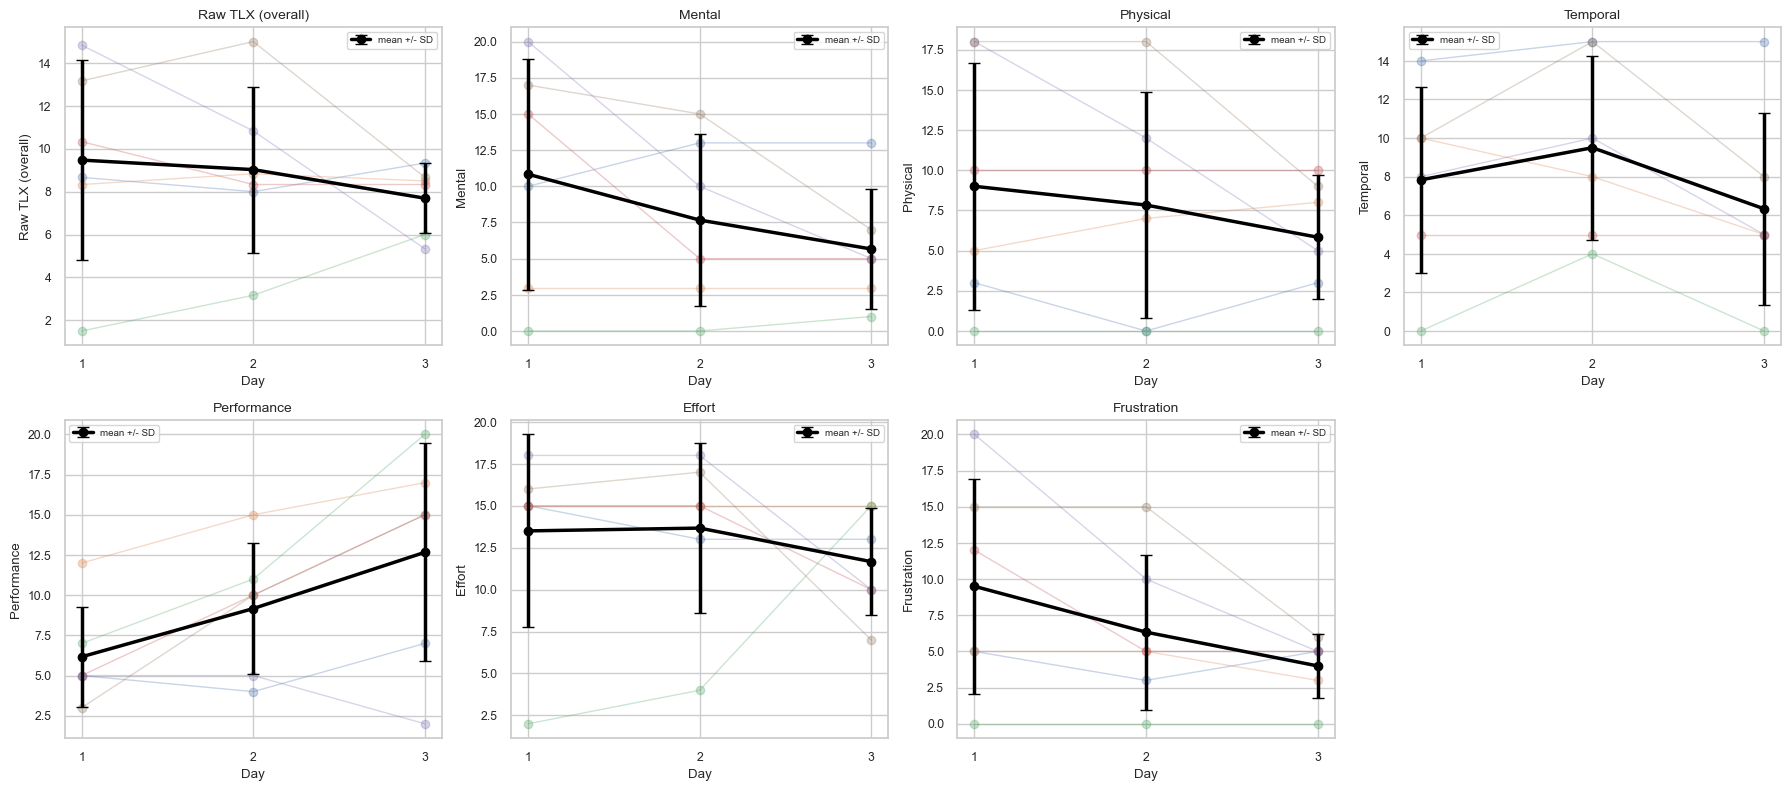

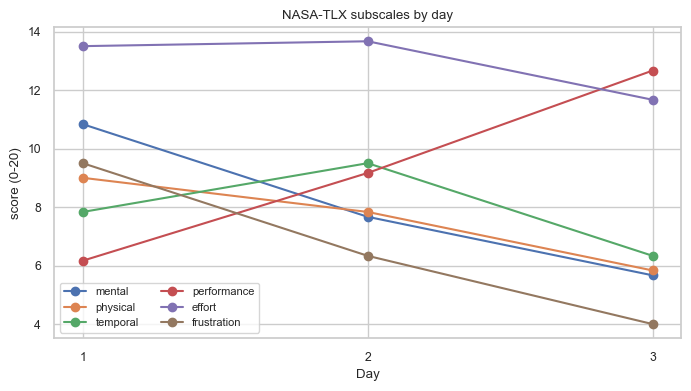

In [21]:
# ---- NASA-TLX line charts by day (mean +/- SD), like the learning curves ----
def tlx_curve(metric, ylabel, ax):
    for pid, g in tlx.groupby("participant_id"):
        g = g.sort_values("day")
        ax.plot(g["day"], g[metric], marker="o", alpha=0.30, lw=1)
    gd = tlx.groupby("day")[metric]; m, sd = gd.mean(), gd.std()
    ax.errorbar(m.index, m.values, yerr=sd.values, marker="o", color="black",
                lw=2.5, capsize=4, label="mean +/- SD")
    ax.set_xlabel("Day"); ax.set_ylabel(ylabel); ax.set_title(ylabel, fontsize=10); ax.legend(fontsize=7)

panels = [("raw_tlx", "Raw TLX (overall)")] + [(s, s.capitalize()) for s in TLX_SUBSCALES]
fig, axes = plt.subplots(2, 4, figsize=(18, 8)); axes = axes.ravel()
for (m, l), ax in zip(panels, axes):
    tlx_curve(m, l, ax)
for ax in axes[len(panels):]:
    ax.axis("off")
plt.tight_layout(); plt.savefig(OUT_DIR / "nasa_tlx_by_day.png", dpi=150); plt.show()

# all 6 subscales overlaid (group means) on one axis
plt.figure(figsize=(7, 4))
for s in TLX_SUBSCALES:
    gm = tlx.groupby("day")[s].mean()
    plt.plot(gm.index, gm.values, marker="o", label=s)
plt.xlabel("Day"); plt.ylabel(f"score (0-{SCALE_MAX})")
plt.title("NASA-TLX subscales by day"); plt.legend(fontsize=8, ncol=2)
plt.tight_layout(); plt.savefig(OUT_DIR / "nasa_tlx_subscales_by_day.png", dpi=150); plt.show()


In [22]:
# ---- NASA-TLX stats by day (reuse rm_test: RM-ANOVA + Friedman + trend) ----
print("#" * 78 + "\n#  NASA-TLX workload vs day\n" + "#" * 78)
tlx_res = []
for dv in ["raw_tlx"] + TLX_SUBSCALES:
    r = rm_test(dv, data=tlx)
    if r:
        r["block"] = "TLX"; tlx_res.append(r)

tlx_stats = pd.DataFrame(tlx_res)
front = ["block", "dv", "n", "F", "anova_p", "partial_eta2", "trend_p", "friedman_p", "kendall_w"]
tlx_stats = tlx_stats[[c for c in front if c in tlx_stats.columns]
                      + [c for c in tlx_stats.columns if c not in front]].round(4)
tlx_stats.to_csv(OUT_DIR / "stats_nasa_tlx.csv", index=False)
print("\nSaved -> analysis_output/stats_nasa_tlx.csv")
display(tlx_stats)


##############################################################################
#  NASA-TLX workload vs day
##############################################################################

=== raw_tlx   (n=6 complete participants) ===
   day means: d1=9.47, d2=9.03, d3=7.69
   RM-ANOVA : F(2,10) =  0.728,  p = 0.5066,  partial eta2 = 0.127
   Friedman : chi2(2) =  0.087,  p = 0.9575,  Kendall W = 0.007
   Trend    : slope/day = -0.8889,  t(5) = -0.90,  p = 0.4079
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.6510  (Holm 1.0000)
      day2 vs day3:  t-p = 0.4215  (Holm 1.0000)
      day1 vs day3:  t-p = 0.4079  (Holm 1.0000)

=== mental   (n=6 complete participants) ===
   day means: d1=10.8, d2=7.67, d3=5.67
   RM-ANOVA : F(2,10) =  2.475,  p = 0.1339,  partial eta2 = 0.331
   Friedman : chi2(2) =  0.824,  p = 0.6625,  Kendall W = 0.069
   Trend    : slope/day = -2.583,  t(5) = -1.71,  p = 0.1485
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.2196  (Holm 


=== effort   (n=6 complete participants) ===
   day means: d1=13.5, d2=13.7, d3=11.7
   RM-ANOVA : F(2,10) =  0.359,  p = 0.7071,  partial eta2 = 0.067
   Friedman : chi2(2) =  2.235,  p = 0.3270,  Kendall W = 0.186
   Trend    : slope/day = -0.9167,  t(5) = -0.56,  p = 0.6004
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.7711  (Holm 1.0000)
      day2 vs day3:  t-p = 0.5457  (Holm 1.0000)
      day1 vs day3:  t-p = 0.6004  (Holm 1.0000)

=== frustration   (n=6 complete participants) ===
   day means: d1=9.5, d2=6.33, d3=4
   RM-ANOVA : F(2,10) =  3.900,  p = 0.0559,  partial eta2 = 0.438
   Friedman : chi2(2) =  5.375,  p = 0.0681,  Kendall W = 0.448
   Trend    : slope/day = -2.75,  t(5) = -2.26,  p = 0.0732
   post-hoc (paired t, Holm-adj):
      day1 vs day2:  t-p = 0.1317  (Holm 0.2635)
      day2 vs day3:  t-p = 0.2156  (Holm 0.2635)
      day1 vs day3:  t-p = 0.0732  (Holm 0.2197)

Saved -> analysis_output/stats_nasa_tlx.csv


,block,dv,n,F,anova_p,partial_eta2,trend_p,friedman_p,kendall_w,friedman_chi2,trend_slope,mean_d1,mean_d2,mean_d3,holm_p_1v2,holm_p_2v3,holm_p_1v3
0,TLX,raw_tlx,6,0.7284,0.5066,0.1272,0.4079,0.9575,0.0072,0.0870,-0.8889,9.4722,9.0278,7.6944,1.0000,1.0000,1.0000
1,TLX,mental,6,2.4747,0.1339,0.3311,0.1485,0.6625,0.0686,0.8235,-2.5833,10.8333,7.6667,5.6667,0.4456,0.4456,0.4456
2,TLX,physical,6,1.2980,0.3154,0.2061,0.2734,0.8071,0.0357,0.4286,-1.5833,9.0000,7.8333,5.8333,0.8202,0.8202,0.8202
3,TLX,temporal,6,4.6246,0.0378,0.4805,0.1647,0.0917,0.3981,4.7778,-0.7500,7.8333,9.5000,6.3333,0.3293,0.1163,0.3293
4,TLX,performance,6,5.8978,0.0203,0.5412,0.0523,0.0839,0.4130,4.9565,3.2500,6.1667,9.1667,12.6667,0.1570,0.1570,0.1570
5,TLX,effort,6,0.3589,0.7071,0.0670,0.6004,0.3270,0.1863,2.2353,-0.9167,13.5000,13.6667,11.6667,1.0000,1.0000,1.0000
6,TLX,frustration,6,3.9005,0.0559,0.4382,0.0732,0.0681,0.4479,5.3750,-2.7500,9.5000,6.3333,4.0000,0.2635,0.2635,0.2197


## 8. Export aggregated tables

Saved under `analysis_output/` for the report.

In [23]:
if len(perf):
    perf.to_csv(OUT_DIR / "trial_performance.csv", index=False)
if len(selections):
    selections.to_csv(OUT_DIR / "selection_events.csv", index=False)
if len(session_metrics):
    session_metrics.to_csv(OUT_DIR / "session_metrics.csv", index=False)
if len(day_metrics):
    day_metrics.to_csv(OUT_DIR / "day_metrics.csv", index=False)

print("Wrote to", OUT_DIR.resolve())
for f in sorted(OUT_DIR.glob("*")):
    print("  ", f.name)


Wrote to /Users/yejipark/Documents/GitHub/Gaze_experiments/analysis/analysis_output
   README.md
   day_metrics.csv
   early_late_by_day.png
   early_late_mechanism.png
   error_rates_by_day.png
   error_type_absolute_by_day.png
   error_type_rates_bar_by_day.png
   error_type_rates_by_day.png
   gaze_key_timeline_P01_day1_allday_x.png
   gaze_key_timeline_P01_day1_experiment_1_x.png
   gaze_pinch_latency_by_day.png
   gaze_pinch_latency_hist_by_day.png
   gazepinch_latencies_by_day.png
   learning_curves.png
   nasa_tlx.csv
   nasa_tlx_by_day.png
   nasa_tlx_processed.csv
   nasa_tlx_subscales_by_day.png
   rq3_scatter.png
   selection_events.csv
   session_metrics.csv
   stats_nasa_tlx.csv
   stats_rm_anova.csv
   stats_rq3_rmcorr.csv
   trial_performance.csv
   trigger_offset_by_day.png
   trigger_offset_by_day_boxplot.png
